In [2]:
# Cell 1 - Setup, paths, reproducibility, and environment report

import os
import sys
import json
import time
import random
import platform
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
)

import joblib

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader


# ---------------------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------------------

SEED = 42

def set_seed(seed: int = 42) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Stable runs. This may slightly reduce GPU throughput, but keeps
    # the notebook behavior easier to reproduce.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)
warnings.filterwarnings("ignore")


# ---------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------

PROJECT_ROOT = Path.cwd().resolve()

DATA_DIR = PROJECT_ROOT / "data" / "nbaiot"

OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"
MODELS_DIR = OUTPUT_DIR / "models"
LOGS_DIR = OUTPUT_DIR / "logs"

for folder in [OUTPUT_DIR, FIGURES_DIR, TABLES_DIR, MODELS_DIR, LOGS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)


# ---------------------------------------------------------------------
# Compute device
# ---------------------------------------------------------------------

CUDA_AVAILABLE = torch.cuda.is_available()

if CUDA_AVAILABLE:
    DEVICE = torch.device("cuda")
    GPU_NAME = torch.cuda.get_device_name(0)
    GPU_COUNT = torch.cuda.device_count()
    CUDA_VERSION = torch.version.cuda
    GPU_MEMORY_GB = round(torch.cuda.get_device_properties(0).total_memory / (1024 ** 3), 2)
else:
    DEVICE = torch.device("cpu")
    GPU_NAME = "None"
    GPU_COUNT = 0
    CUDA_VERSION = None
    GPU_MEMORY_GB = None


# ---------------------------------------------------------------------
# Experiment configuration
# ---------------------------------------------------------------------

EXPERIMENT_NAME = "UVIF-IoT-WiMob2026"
TASK_NAME = "binary_iot_intrusion_detection"

CONFIG = {
    "experiment_name": EXPERIMENT_NAME,
    "task_name": TASK_NAME,
    "label_mode": "binary",

    "seed": SEED,

    "data_dir": str(DATA_DIR),
    "output_dir": str(OUTPUT_DIR),
    "figures_dir": str(FIGURES_DIR),
    "tables_dir": str(TABLES_DIR),
    "models_dir": str(MODELS_DIR),
    "logs_dir": str(LOGS_DIR),

    # Split settings
    "test_size": 0.20,
    "validation_size": 0.20,
    "stratify_splits": True,

    # Sampling keeps the first full run manageable.
    # We can increase these after the pipeline is verified.
    "use_sampling": True,
    "max_samples_total": 300_000,
    "max_samples_per_file": 25_000,

    # Training settings
    "batch_size": 512,
    "num_workers": 0,
    "mlp_hidden_dims": [128, 64],
    "dropout": 0.20,
    "learning_rate": 1e-3,
    "weight_decay": 1e-5,
    "max_epochs": 30,
    "early_stopping_patience": 5,

    # Calibration and uncertainty
    "calibration_bins": 15,

    # Adversarial evaluation
    "fgsm_epsilons": [0.005, 0.01, 0.02],
    "run_pgd": False,
    "pgd_epsilon": 0.01,
    "pgd_alpha": 0.002,
    "pgd_steps": 10,

    # Feature-efficiency experiments
    "feature_budgets": [10, 20, 30, 50, "all"],
}


# ---------------------------------------------------------------------
# Dataset check
# ---------------------------------------------------------------------

if DATA_DIR.exists():
    DATA_FILES = sorted(DATA_DIR.rglob("*.csv"))
else:
    DATA_FILES = []

DATASET_STATUS = {
    "data_dir_exists": DATA_DIR.exists(),
    "csv_files_detected": len(DATA_FILES),
    "first_files": [str(p.relative_to(DATA_DIR)) for p in DATA_FILES[:12]],
}


# ---------------------------------------------------------------------
# Environment report
# ---------------------------------------------------------------------

ENV_REPORT = {
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "python": sys.version.replace("\n", " "),
    "platform": platform.platform(),
    "processor": platform.processor(),
    "machine": platform.machine(),

    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit_learn": sklearn.__version__,
    "matplotlib": matplotlib.__version__,
    "torch": torch.__version__,

    "cuda_available": CUDA_AVAILABLE,
    "cuda_version": CUDA_VERSION,
    "gpu_count": GPU_COUNT,
    "gpu_name": GPU_NAME,
    "gpu_memory_gb": GPU_MEMORY_GB,
    "selected_device": str(DEVICE),

    "cpu_count": os.cpu_count(),
    "seed": SEED,

    "dataset_status": DATASET_STATUS,
    "config": CONFIG,
}

env_report_path = LOGS_DIR / "environment_and_config.json"
with open(env_report_path, "w", encoding="utf-8") as f:
    json.dump(ENV_REPORT, f, indent=4)


# ---------------------------------------------------------------------
# Console output
# ---------------------------------------------------------------------

print("=" * 80)
print(f"{EXPERIMENT_NAME} | Reproducible Experiment Setup")
print("=" * 80)

print("\n[Paths]")
print(f"Project root : {PROJECT_ROOT}")
print(f"Data dir     : {DATA_DIR}")
print(f"Outputs dir  : {OUTPUT_DIR}")
print(f"Figures dir  : {FIGURES_DIR}")
print(f"Tables dir   : {TABLES_DIR}")
print(f"Models dir   : {MODELS_DIR}")
print(f"Logs dir     : {LOGS_DIR}")

print("\n[Environment]")
print(f"Python       : {sys.version.split()[0]}")
print(f"Platform     : {platform.platform()}")
print(f"NumPy        : {np.__version__}")
print(f"Pandas       : {pd.__version__}")
print(f"Scikit-learn : {sklearn.__version__}")
print(f"Matplotlib   : {matplotlib.__version__}")
print(f"PyTorch      : {torch.__version__}")

print("\n[Compute]")
print(f"Selected device : {DEVICE}")
print(f"CUDA available  : {CUDA_AVAILABLE}")
print(f"CUDA version    : {CUDA_VERSION}")
print(f"GPU count       : {GPU_COUNT}")
print(f"GPU name        : {GPU_NAME}")
print(f"GPU memory      : {GPU_MEMORY_GB} GB")
print(f"CPU cores       : {os.cpu_count()}")

print("\n[Reproducibility]")
print(f"Seed                  : {SEED}")
print(f"cuDNN deterministic   : {torch.backends.cudnn.deterministic}")
print(f"cuDNN benchmark       : {torch.backends.cudnn.benchmark}")

print("\n[Dataset]")
print(f"Data directory exists : {DATASET_STATUS['data_dir_exists']}")
print(f"CSV files detected    : {DATASET_STATUS['csv_files_detected']}")
print("First detected files:")
for name in DATASET_STATUS["first_files"]:
    print(f"  - {name}")

print("\n[Experiment]")
print(f"Task                  : {CONFIG['task_name']}")
print(f"Label mode            : {CONFIG['label_mode']}")
print(f"Sampling enabled      : {CONFIG['use_sampling']}")
print(f"Max total samples     : {CONFIG['max_samples_total']}")
print(f"Max samples per file  : {CONFIG['max_samples_per_file']}")
print(f"Batch size            : {CONFIG['batch_size']}")
print(f"MLP hidden layers     : {CONFIG['mlp_hidden_dims']}")
print(f"Max epochs            : {CONFIG['max_epochs']}")
print(f"FGSM epsilons         : {CONFIG['fgsm_epsilons']}")
print(f"PGD enabled           : {CONFIG['run_pgd']}")
print(f"Feature budgets       : {CONFIG['feature_budgets']}")

print("\n[Saved]")
print(f"Environment report    : {env_report_path}")

print("\nCell 1 complete.")
print("=" * 80)

UVIF-IoT-WiMob2026 | Reproducible Experiment Setup

[Paths]
Project root : F:\MBZUAI UAE\16-Conference\1-UVIF-IoT-WiMob26\UVIF-IoT-WiMob2026
Data dir     : F:\MBZUAI UAE\16-Conference\1-UVIF-IoT-WiMob26\UVIF-IoT-WiMob2026\data\nbaiot
Outputs dir  : F:\MBZUAI UAE\16-Conference\1-UVIF-IoT-WiMob26\UVIF-IoT-WiMob2026\outputs
Figures dir  : F:\MBZUAI UAE\16-Conference\1-UVIF-IoT-WiMob26\UVIF-IoT-WiMob2026\outputs\figures
Tables dir   : F:\MBZUAI UAE\16-Conference\1-UVIF-IoT-WiMob26\UVIF-IoT-WiMob2026\outputs\tables
Models dir   : F:\MBZUAI UAE\16-Conference\1-UVIF-IoT-WiMob26\UVIF-IoT-WiMob2026\outputs\models
Logs dir     : F:\MBZUAI UAE\16-Conference\1-UVIF-IoT-WiMob26\UVIF-IoT-WiMob2026\outputs\logs

[Environment]
Python       : 3.10.20
Platform     : Windows-10-10.0.26200-SP0
NumPy        : 2.2.5
Pandas       : 2.3.3
Scikit-learn : 1.7.2
Matplotlib   : 3.10.8
PyTorch      : 2.11.0+cu126

[Compute]
Selected device : cuda
CUDA available  : True
CUDA version    : 12.6
GPU count       : 1
GP

In [3]:
# Cell 2 - Dataset inventory and label inference

def parse_nbaiot_filename(path: Path) -> dict:
    """
    Parse N-BaIoT filenames such as:
      1.benign.csv
      1.gafgyt.combo.csv
      1.mirai.udpplain.csv

    Returns metadata used later for binary labels and optional family/subtype analysis.
    """
    name = path.name
    stem = path.stem
    parts = stem.split(".")

    out = {
        "file_name": name,
        "relative_path": str(path.relative_to(DATA_DIR)),
        "is_data_file": False,
        "device_id": None,
        "traffic_family": None,
        "attack_subtype": None,
        "binary_label": None,
        "binary_target": None,
    }

    if len(parts) < 2:
        return out

    if not parts[0].isdigit():
        return out

    device_id = int(parts[0])
    family = parts[1].lower()

    if family == "benign":
        out.update({
            "is_data_file": True,
            "device_id": device_id,
            "traffic_family": "benign",
            "attack_subtype": "benign",
            "binary_label": "benign",
            "binary_target": 0,
        })

    elif family in {"gafgyt", "mirai"}:
        subtype = ".".join(parts[2:]).lower() if len(parts) > 2 else "unknown"
        out.update({
            "is_data_file": True,
            "device_id": device_id,
            "traffic_family": family,
            "attack_subtype": subtype,
            "binary_label": "attack",
            "binary_target": 1,
        })

    return out


def count_csv_rows(path: Path) -> int:
    """
    Count data rows without loading the full file.
    Assumes one header row, which is true for the N-BaIoT CSV files.
    """
    with open(path, "rb") as f:
        n_lines = sum(1 for _ in f)
    return max(n_lines - 1, 0)


def inspect_csv_columns(path: Path) -> tuple[int, list[str]]:
    sample = pd.read_csv(path, nrows=5)
    return sample.shape[1], list(sample.columns)


records = []

for csv_path in sorted(DATA_DIR.rglob("*.csv")):
    meta = parse_nbaiot_filename(csv_path)

    file_size_mb = csv_path.stat().st_size / (1024 ** 2)
    row_count = count_csv_rows(csv_path)

    try:
        n_columns, columns = inspect_csv_columns(csv_path)
        read_status = "ok"
    except Exception as e:
        n_columns, columns = None, []
        read_status = f"error: {type(e).__name__}: {e}"

    meta.update({
        "file_size_mb": round(file_size_mb, 3),
        "n_rows": row_count,
        "n_columns": n_columns,
        "read_status": read_status,
        "columns": columns,
    })

    records.append(meta)


inventory_df = pd.DataFrame(records)

data_inventory_df = inventory_df[inventory_df["is_data_file"]].copy()
metadata_inventory_df = inventory_df[~inventory_df["is_data_file"]].copy()

if data_inventory_df.empty:
    raise RuntimeError(
        "No N-BaIoT data files were detected. Check DATA_DIR and file names."
    )

# Check whether all data files share the same feature columns.
reference_columns = data_inventory_df.iloc[0]["columns"]
data_inventory_df["same_columns_as_reference"] = data_inventory_df["columns"].apply(
    lambda cols: cols == reference_columns
)

consistent_columns = bool(data_inventory_df["same_columns_as_reference"].all())
n_features = len(reference_columns)

summary_by_label = (
    data_inventory_df
    .groupby(["binary_label", "binary_target"], as_index=False)
    .agg(
        n_files=("file_name", "count"),
        n_rows=("n_rows", "sum"),
        size_mb=("file_size_mb", "sum"),
    )
    .sort_values("binary_target")
)

summary_by_family = (
    data_inventory_df
    .groupby(["traffic_family"], as_index=False)
    .agg(
        n_files=("file_name", "count"),
        n_rows=("n_rows", "sum"),
        size_mb=("file_size_mb", "sum"),
    )
    .sort_values("traffic_family")
)

summary_by_device_family = (
    data_inventory_df
    .groupby(["device_id", "traffic_family"], as_index=False)
    .agg(
        n_files=("file_name", "count"),
        n_rows=("n_rows", "sum"),
        size_mb=("file_size_mb", "sum"),
    )
    .sort_values(["device_id", "traffic_family"])
)

# Save tables for reproducibility and paper reporting.
inventory_path = TABLES_DIR / "dataset_file_inventory.csv"
data_inventory_path = TABLES_DIR / "dataset_data_files_inventory.csv"
label_summary_path = TABLES_DIR / "dataset_summary_by_binary_label.csv"
family_summary_path = TABLES_DIR / "dataset_summary_by_family.csv"
device_family_summary_path = TABLES_DIR / "dataset_summary_by_device_family.csv"

inventory_df.drop(columns=["columns"]).to_csv(inventory_path, index=False)
data_inventory_df.drop(columns=["columns"]).to_csv(data_inventory_path, index=False)
summary_by_label.to_csv(label_summary_path, index=False)
summary_by_family.to_csv(family_summary_path, index=False)
summary_by_device_family.to_csv(device_family_summary_path, index=False)

# Save feature names.
feature_names = list(reference_columns)
feature_names_path = TABLES_DIR / "feature_names.csv"
pd.DataFrame({"feature": feature_names}).to_csv(feature_names_path, index=False)

print("=" * 80)
print("Cell 2 | N-BaIoT Dataset Inventory")
print("=" * 80)

print("\n[Files]")
print(f"Total CSV files found        : {len(inventory_df)}")
print(f"Detected data files          : {len(data_inventory_df)}")
print(f"Detected metadata/other CSVs : {len(metadata_inventory_df)}")

if len(metadata_inventory_df) > 0:
    print("\nMetadata/other CSV files excluded from modeling:")
    for name in metadata_inventory_df["file_name"].tolist():
        print(f"  - {name}")

print("\n[Feature Columns]")
print(f"Number of feature columns    : {n_features}")
print(f"Columns consistent across data files: {consistent_columns}")

if not consistent_columns:
    bad_files = data_inventory_df.loc[
        ~data_inventory_df["same_columns_as_reference"], "file_name"
    ].tolist()
    print("Files with different columns:")
    for name in bad_files:
        print(f"  - {name}")

print("\n[Binary Label Summary]")
print(summary_by_label.to_string(index=False))

print("\n[Traffic Family Summary]")
print(summary_by_family.to_string(index=False))

print("\n[Device x Family Summary]")
print(summary_by_device_family.to_string(index=False))

print("\n[First 10 feature names]")
for feature in feature_names[:10]:
    print(f"  - {feature}")

print("\n[Saved]")
print(f"Full inventory          : {inventory_path}")
print(f"Data-file inventory     : {data_inventory_path}")
print(f"Binary label summary    : {label_summary_path}")
print(f"Family summary          : {family_summary_path}")
print(f"Device-family summary   : {device_family_summary_path}")
print(f"Feature names           : {feature_names_path}")

print("\nCell 2 complete.")
print("=" * 80)

Cell 2 | N-BaIoT Dataset Inventory

[Files]
Total CSV files found        : 92
Detected data files          : 89
Detected metadata/other CSVs : 3

Metadata/other CSV files excluded from modeling:
  - data_summary.csv
  - device_info.csv
  - features.csv

[Feature Columns]
Number of feature columns    : 115
Columns consistent across data files: True

[Binary Label Summary]
binary_label  binary_target  n_files  n_rows  size_mb
      benign            0.0        9  555932  572.603
      attack            1.0       80 6506674 7191.097

[Traffic Family Summary]
traffic_family  n_files  n_rows  size_mb
        benign        9  555932  572.603
        gafgyt       45 2838272 2595.581
         mirai       35 3668402 4595.516

[Device x Family Summary]
 device_id traffic_family  n_files  n_rows  size_mb
       1.0         benign        1   49548   44.382
       1.0         gafgyt        5  316650  292.585
       1.0          mirai        5  652100  804.246
       2.0         benign        1   13

Cell 3 | Loading Pilot Dataset

[Sampling policy]
Sampling enabled       : True
Max samples total      : 300000
Max samples per file   : 25000
Target benign samples  : 150000
Target attack samples  : 150000


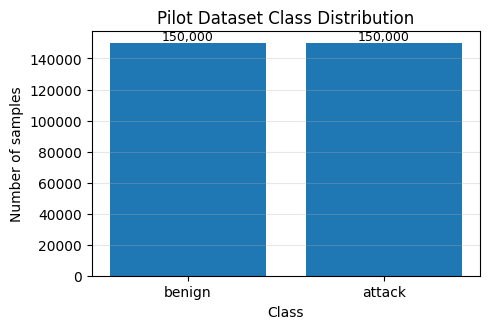

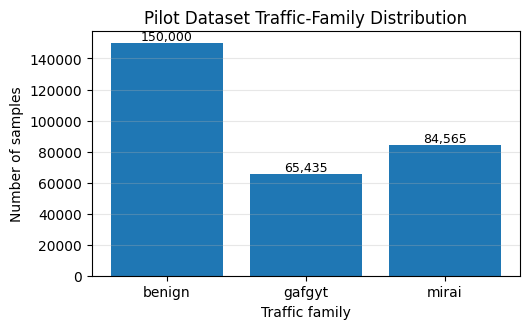


[Loaded dataset]
Samples loaded       : 300,000
Feature count        : 115
Label vector shape   : (300000,)
Feature matrix shape : (300000, 115)

[Sample summary by binary label]
binary_label  binary_target  sampled_rows
      benign              0        150000
      attack              1        150000

[Sample summary by traffic family]
traffic_family  sampled_rows
        benign        150000
        gafgyt         65435
         mirai         84565

[Sample summary by device and family]
 device_id traffic_family  sampled_rows
         1         benign         16778
         1         gafgyt          7303
         1          mirai         15034
         2         benign          6948
         2         gafgyt          7163
         2          mirai         11809
         3         benign         13959
         3         gafgyt          7296
         4         benign         25000
         4         gafgyt          7212
         4          mirai         14081
         5         beni

In [4]:
# Cell 3 - Load a reproducible pilot dataset

def sample_rows_from_csv(path: Path, n_rows: int, max_rows: int, seed: int) -> pd.DataFrame:
    """
    Reproducibly sample up to max_rows from a CSV file.

    For the pilot run, files are read once and sampled in memory.
    This is simpler and acceptable because the per-file cap is small.
    """
    use_n = min(n_rows, max_rows)

    if use_n == n_rows:
        return pd.read_csv(path)

    # pandas sample is deterministic with random_state.
    df = pd.read_csv(path)
    return df.sample(n=use_n, random_state=seed)


# Pilot loading policy.
# We keep the total dataset balanced enough for the first full pipeline.
BENIGN_TARGET_TOTAL = min(
    int(summary_by_label.loc[summary_by_label["binary_label"] == "benign", "n_rows"].iloc[0]),
    CONFIG["max_samples_total"] // 2,
)
ATTACK_TARGET_TOTAL = CONFIG["max_samples_total"] - BENIGN_TARGET_TOTAL

label_targets = {
    "benign": BENIGN_TARGET_TOTAL,
    "attack": ATTACK_TARGET_TOTAL,
}

print("=" * 80)
print("Cell 3 | Loading Pilot Dataset")
print("=" * 80)

print("\n[Sampling policy]")
print(f"Sampling enabled       : {CONFIG['use_sampling']}")
print(f"Max samples total      : {CONFIG['max_samples_total']}")
print(f"Max samples per file   : {CONFIG['max_samples_per_file']}")
print(f"Target benign samples  : {label_targets['benign']}")
print(f"Target attack samples  : {label_targets['attack']}")

loaded_parts = []
load_records = []

for label_name, target_total in label_targets.items():
    files_for_label = (
        data_inventory_df[data_inventory_df["binary_label"] == label_name]
        .sort_values(["device_id", "traffic_family", "attack_subtype", "file_name"])
        .reset_index(drop=True)
    )

    available_rows = int(files_for_label["n_rows"].sum())
    target_total = min(target_total, available_rows)

    # Allocate samples approximately proportional to file sizes.
    raw_alloc = files_for_label["n_rows"] / available_rows * target_total
    alloc = np.floor(raw_alloc).astype(int)

    # Ensure non-empty files get at least one row if possible.
    alloc = np.where((files_for_label["n_rows"] > 0) & (alloc == 0), 1, alloc)

    # Enforce per-file cap.
    alloc = np.minimum(alloc, CONFIG["max_samples_per_file"])

    # If the cap reduces the total too much, distribute remaining capacity.
    remaining = int(target_total - alloc.sum())
    if remaining > 0:
        capacity = np.minimum(
            files_for_label["n_rows"].to_numpy(),
            CONFIG["max_samples_per_file"]
        ) - alloc

        while remaining > 0 and capacity.sum() > 0:
            for i in range(len(alloc)):
                if remaining <= 0:
                    break
                if capacity[i] > 0:
                    alloc[i] += 1
                    capacity[i] -= 1
                    remaining -= 1

    for row_idx, row in files_for_label.iterrows():
        n_take = int(alloc[row_idx])
        if n_take <= 0:
            continue

        path = DATA_DIR / row["relative_path"]
        local_seed = SEED + int(row["device_id"] * 1000) + row_idx

        part = sample_rows_from_csv(
            path=path,
            n_rows=int(row["n_rows"]),
            max_rows=n_take,
            seed=local_seed,
        )

        part["binary_label"] = row["binary_label"]
        part["binary_target"] = int(row["binary_target"])
        part["device_id"] = int(row["device_id"])
        part["traffic_family"] = row["traffic_family"]
        part["attack_subtype"] = row["attack_subtype"]
        part["source_file"] = row["file_name"]

        loaded_parts.append(part)

        load_records.append({
            "file_name": row["file_name"],
            "device_id": int(row["device_id"]),
            "traffic_family": row["traffic_family"],
            "attack_subtype": row["attack_subtype"],
            "binary_label": row["binary_label"],
            "available_rows": int(row["n_rows"]),
            "sampled_rows": n_take,
        })

sampled_df = pd.concat(loaded_parts, axis=0, ignore_index=True)

# Shuffle once after concatenation.
sampled_df = sampled_df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

label_cols = [
    "binary_label",
    "binary_target",
    "device_id",
    "traffic_family",
    "attack_subtype",
    "source_file",
]

X_raw = sampled_df[feature_names].copy()
y = sampled_df["binary_target"].astype(int).copy()
sample_meta_df = sampled_df[label_cols].copy()

# Basic cleanup. We do not impute silently if something unexpected appears.
X_raw = X_raw.replace([np.inf, -np.inf], np.nan)

missing_total = int(X_raw.isna().sum().sum())
if missing_total > 0:
    raise ValueError(
        f"Unexpected missing or infinite values detected in X_raw: {missing_total}. "
        "We should inspect the dataset before continuing."
    )

load_plan_df = pd.DataFrame(load_records)

sample_summary_by_label = (
    sample_meta_df
    .groupby(["binary_label", "binary_target"], as_index=False)
    .size()
    .rename(columns={"size": "sampled_rows"})
    .sort_values("binary_target")
)

sample_summary_by_family = (
    sample_meta_df
    .groupby(["traffic_family"], as_index=False)
    .size()
    .rename(columns={"size": "sampled_rows"})
    .sort_values("traffic_family")
)

sample_summary_by_device_family = (
    sample_meta_df
    .groupby(["device_id", "traffic_family"], as_index=False)
    .size()
    .rename(columns={"size": "sampled_rows"})
    .sort_values(["device_id", "traffic_family"])
)

# Save reproducibility tables.
load_plan_path = TABLES_DIR / "pilot_sampling_plan.csv"
sample_label_summary_path = TABLES_DIR / "pilot_sample_summary_by_binary_label.csv"
sample_family_summary_path = TABLES_DIR / "pilot_sample_summary_by_family.csv"
sample_device_family_summary_path = TABLES_DIR / "pilot_sample_summary_by_device_family.csv"

load_plan_df.to_csv(load_plan_path, index=False)
sample_summary_by_label.to_csv(sample_label_summary_path, index=False)
sample_summary_by_family.to_csv(sample_family_summary_path, index=False)
sample_summary_by_device_family.to_csv(sample_device_family_summary_path, index=False)

# Save a compact metadata file. The feature matrix itself is not saved here
# to avoid creating a large duplicate file in the repository.
pilot_info = {
    "n_samples": int(len(X_raw)),
    "n_features": int(X_raw.shape[1]),
    "class_counts": sample_meta_df["binary_label"].value_counts().to_dict(),
    "family_counts": sample_meta_df["traffic_family"].value_counts().to_dict(),
    "sampling_config": {
        "max_samples_total": CONFIG["max_samples_total"],
        "max_samples_per_file": CONFIG["max_samples_per_file"],
        "seed": SEED,
    },
}
pilot_info_path = LOGS_DIR / "pilot_dataset_info.json"
with open(pilot_info_path, "w", encoding="utf-8") as f:
    json.dump(pilot_info, f, indent=4)

# ---------------------------------------------------------------------
# Figure 1: binary label distribution
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(5.0, 3.4))
plot_df = sample_summary_by_label.copy()
ax.bar(plot_df["binary_label"], plot_df["sampled_rows"])
ax.set_title("Pilot Dataset Class Distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Number of samples")
ax.grid(axis="y", alpha=0.3)

for idx, value in enumerate(plot_df["sampled_rows"]):
    ax.text(idx, value, f"{value:,}", ha="center", va="bottom", fontsize=9)

fig.tight_layout()
class_dist_png = FIGURES_DIR / "pilot_class_distribution.png"
class_dist_pdf = FIGURES_DIR / "pilot_class_distribution.pdf"
fig.savefig(class_dist_png, dpi=300, bbox_inches="tight")
fig.savefig(class_dist_pdf, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------------------
# Figure 2: traffic family distribution
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(5.4, 3.4))
family_plot_df = sample_summary_by_family.copy()
ax.bar(family_plot_df["traffic_family"], family_plot_df["sampled_rows"])
ax.set_title("Pilot Dataset Traffic-Family Distribution")
ax.set_xlabel("Traffic family")
ax.set_ylabel("Number of samples")
ax.grid(axis="y", alpha=0.3)

for idx, value in enumerate(family_plot_df["sampled_rows"]):
    ax.text(idx, value, f"{value:,}", ha="center", va="bottom", fontsize=9)

fig.tight_layout()
family_dist_png = FIGURES_DIR / "pilot_family_distribution.png"
family_dist_pdf = FIGURES_DIR / "pilot_family_distribution.pdf"
fig.savefig(family_dist_png, dpi=300, bbox_inches="tight")
fig.savefig(family_dist_pdf, bbox_inches="tight")
plt.show()

print("\n[Loaded dataset]")
print(f"Samples loaded       : {len(X_raw):,}")
print(f"Feature count        : {X_raw.shape[1]}")
print(f"Label vector shape   : {y.shape}")
print(f"Feature matrix shape : {X_raw.shape}")

print("\n[Sample summary by binary label]")
print(sample_summary_by_label.to_string(index=False))

print("\n[Sample summary by traffic family]")
print(sample_summary_by_family.to_string(index=False))

print("\n[Sample summary by device and family]")
print(sample_summary_by_device_family.to_string(index=False))

print("\n[Data quality]")
print(f"Missing/infinite values after cleanup: {missing_total}")

print("\n[Saved]")
print(f"Sampling plan                    : {load_plan_path}")
print(f"Binary sample summary            : {sample_label_summary_path}")
print(f"Family sample summary            : {sample_family_summary_path}")
print(f"Device-family sample summary     : {sample_device_family_summary_path}")
print(f"Pilot dataset info               : {pilot_info_path}")
print(f"Class distribution PNG/PDF       : {class_dist_png}")
print(f"Traffic family distribution PNG/PDF: {family_dist_png}")

print("\nCell 3 complete.")
print("=" * 80)

Cell 4 | Splits and Feature Scaling


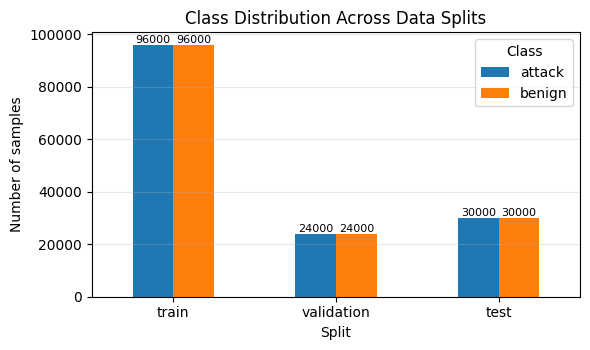


[Split sizes]
     split  n_samples  percentage_of_total
     train     192000                 64.0
validation      48000                 16.0
      test      60000                 20.0

[Class balance by split]
     split  binary_target binary_label  n_samples  percentage
     train              0       benign      96000        50.0
     train              1       attack      96000        50.0
validation              0       benign      24000        50.0
validation              1       attack      24000        50.0
      test              0       benign      30000        50.0
      test              1       attack      30000        50.0

[Traffic family by split]
     split traffic_family  n_samples
      test         benign      30000
      test         gafgyt      13125
      test          mirai      16875
     train         benign      96000
     train         gafgyt      41946
     train          mirai      54054
validation         benign      24000
validation         gafgyt     

In [5]:
# Cell 4 - Train/validation/test split and preprocessing

print("=" * 80)
print("Cell 4 | Splits and Feature Scaling")
print("=" * 80)

# ---------------------------------------------------------------------
# Split indices first, then use them consistently for X, y, and metadata.
# ---------------------------------------------------------------------

all_idx = np.arange(len(y))

test_size = CONFIG["test_size"]
val_size_from_trainval = CONFIG["validation_size"]

idx_trainval, idx_test = train_test_split(
    all_idx,
    test_size=test_size,
    random_state=SEED,
    stratify=y if CONFIG["stratify_splits"] else None,
)

y_trainval = y.iloc[idx_trainval]

idx_train, idx_val = train_test_split(
    idx_trainval,
    test_size=val_size_from_trainval,
    random_state=SEED,
    stratify=y_trainval if CONFIG["stratify_splits"] else None,
)

# Keep raw feature frames for classical models and feature analysis.
X_train_raw = X_raw.iloc[idx_train].copy()
X_val_raw = X_raw.iloc[idx_val].copy()
X_test_raw = X_raw.iloc[idx_test].copy()

y_train = y.iloc[idx_train].to_numpy(dtype=np.int64)
y_val = y.iloc[idx_val].to_numpy(dtype=np.int64)
y_test = y.iloc[idx_test].to_numpy(dtype=np.int64)

meta_train = sample_meta_df.iloc[idx_train].copy().reset_index(drop=True)
meta_val = sample_meta_df.iloc[idx_val].copy().reset_index(drop=True)
meta_test = sample_meta_df.iloc[idx_test].copy().reset_index(drop=True)

X_train_raw = X_train_raw.reset_index(drop=True)
X_val_raw = X_val_raw.reset_index(drop=True)
X_test_raw = X_test_raw.reset_index(drop=True)


# ---------------------------------------------------------------------
# Scale numeric features.
# The scaler is fitted only on the training split.
# ---------------------------------------------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train_raw).astype(np.float32)
X_val = scaler.transform(X_val_raw).astype(np.float32)
X_test = scaler.transform(X_test_raw).astype(np.float32)

scaler_path = MODELS_DIR / "standard_scaler.joblib"
joblib.dump(scaler, scaler_path)

# These bounds are useful later for adversarial feature-space attacks.
X_train_min = X_train.min(axis=0).astype(np.float32)
X_train_max = X_train.max(axis=0).astype(np.float32)

np.save(MODELS_DIR / "scaled_train_feature_min.npy", X_train_min)
np.save(MODELS_DIR / "scaled_train_feature_max.npy", X_train_max)


# ---------------------------------------------------------------------
# Split summaries
# ---------------------------------------------------------------------

def split_summary_frame(y_array, split_name):
    counts = pd.Series(y_array).value_counts().sort_index()
    rows = []
    for target, count in counts.items():
        label = "benign" if int(target) == 0 else "attack"
        rows.append({
            "split": split_name,
            "binary_target": int(target),
            "binary_label": label,
            "n_samples": int(count),
            "percentage": round(float(count / len(y_array) * 100), 3),
        })
    return pd.DataFrame(rows)


split_summary_df = pd.concat(
    [
        split_summary_frame(y_train, "train"),
        split_summary_frame(y_val, "validation"),
        split_summary_frame(y_test, "test"),
    ],
    axis=0,
    ignore_index=True,
)

split_size_df = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "n_samples": [len(y_train), len(y_val), len(y_test)],
    "percentage_of_total": [
        round(len(y_train) / len(y) * 100, 3),
        round(len(y_val) / len(y) * 100, 3),
        round(len(y_test) / len(y) * 100, 3),
    ],
})

split_family_df = pd.concat(
    [
        meta_train.assign(split="train"),
        meta_val.assign(split="validation"),
        meta_test.assign(split="test"),
    ],
    axis=0,
    ignore_index=True,
)

split_family_summary_df = (
    split_family_df
    .groupby(["split", "traffic_family"], as_index=False)
    .size()
    .rename(columns={"size": "n_samples"})
    .sort_values(["split", "traffic_family"])
)

split_device_family_summary_df = (
    split_family_df
    .groupby(["split", "device_id", "traffic_family"], as_index=False)
    .size()
    .rename(columns={"size": "n_samples"})
    .sort_values(["split", "device_id", "traffic_family"])
)

split_summary_path = TABLES_DIR / "split_summary_by_binary_label.csv"
split_size_path = TABLES_DIR / "split_size_summary.csv"
split_family_path = TABLES_DIR / "split_summary_by_family.csv"
split_device_family_path = TABLES_DIR / "split_summary_by_device_family.csv"

split_summary_df.to_csv(split_summary_path, index=False)
split_size_df.to_csv(split_size_path, index=False)
split_family_summary_df.to_csv(split_family_path, index=False)
split_device_family_summary_df.to_csv(split_device_family_path, index=False)


# ---------------------------------------------------------------------
# Figure: class distribution across splits
# ---------------------------------------------------------------------

plot_df = split_summary_df.pivot(
    index="split",
    columns="binary_label",
    values="n_samples"
).loc[["train", "validation", "test"]]

fig, ax = plt.subplots(figsize=(6.0, 3.6))
plot_df.plot(kind="bar", ax=ax)

ax.set_title("Class Distribution Across Data Splits")
ax.set_xlabel("Split")
ax.set_ylabel("Number of samples")
ax.grid(axis="y", alpha=0.3)
ax.legend(title="Class")
ax.tick_params(axis="x", rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", fontsize=8)

fig.tight_layout()

split_dist_png = FIGURES_DIR / "split_class_distribution.png"
split_dist_pdf = FIGURES_DIR / "split_class_distribution.pdf"

fig.savefig(split_dist_png, dpi=300, bbox_inches="tight")
fig.savefig(split_dist_pdf, bbox_inches="tight")
plt.show()


# ---------------------------------------------------------------------
# Compact preprocessing report
# ---------------------------------------------------------------------

preprocessing_report = {
    "n_total_samples": int(len(y)),
    "n_features": int(X_train.shape[1]),
    "train_samples": int(len(y_train)),
    "validation_samples": int(len(y_val)),
    "test_samples": int(len(y_test)),
    "test_size": float(test_size),
    "validation_size_from_trainval": float(val_size_from_trainval),
    "scaler": "StandardScaler fitted on training split only",
    "feature_dtype_after_scaling": str(X_train.dtype),
    "target_dtype": str(y_train.dtype),
    "scaler_path": str(scaler_path),
}

preprocessing_report_path = LOGS_DIR / "preprocessing_report.json"
with open(preprocessing_report_path, "w", encoding="utf-8") as f:
    json.dump(preprocessing_report, f, indent=4)


print("\n[Split sizes]")
print(split_size_df.to_string(index=False))

print("\n[Class balance by split]")
print(split_summary_df.to_string(index=False))

print("\n[Traffic family by split]")
print(split_family_summary_df.to_string(index=False))

print("\n[Feature scaling]")
print(f"Scaler fitted on          : training split only")
print(f"Scaled train shape        : {X_train.shape}")
print(f"Scaled validation shape   : {X_val.shape}")
print(f"Scaled test shape         : {X_test.shape}")
print(f"Scaled dtype              : {X_train.dtype}")
print(f"Train scaled mean range   : {X_train.mean(axis=0).min():.4f} to {X_train.mean(axis=0).max():.4f}")
print(f"Train scaled std range    : {X_train.std(axis=0).min():.4f} to {X_train.std(axis=0).max():.4f}")

print("\n[Saved]")
print(f"Scaler                         : {scaler_path}")
print(f"Train feature min bounds        : {MODELS_DIR / 'scaled_train_feature_min.npy'}")
print(f"Train feature max bounds        : {MODELS_DIR / 'scaled_train_feature_max.npy'}")
print(f"Split binary summary            : {split_summary_path}")
print(f"Split size summary              : {split_size_path}")
print(f"Split family summary            : {split_family_path}")
print(f"Split device-family summary     : {split_device_family_path}")
print(f"Preprocessing report            : {preprocessing_report_path}")
print(f"Split distribution PNG/PDF      : {split_dist_png}")

print("\nCell 4 complete.")
print("=" * 80)

In [6]:
# Cell 5 - Evaluation, calibration, uncertainty, and plotting utilities

print("=" * 80)
print("Cell 5 | Evaluation Utilities")
print("=" * 80)


# ---------------------------------------------------------------------
# Result stores
# ---------------------------------------------------------------------

clean_results = []
calibration_results = []
robustness_results = []
feature_results = []
ablation_results = []


# ---------------------------------------------------------------------
# Core prediction metrics
# ---------------------------------------------------------------------

def classification_metrics(y_true, y_pred, prefix=None):
    out = {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
    }

    if prefix is not None:
        out = {f"{prefix}_{k}": v for k, v in out.items()}

    return out


def probability_to_prediction(proba):
    proba = np.asarray(proba)

    if proba.ndim == 1:
        return (proba >= 0.5).astype(int)

    return np.argmax(proba, axis=1).astype(int)


def evaluate_classifier_outputs(
    model_name,
    split_name,
    y_true,
    y_pred=None,
    y_proba=None,
    n_features=None,
    notes=""
):
    if y_pred is None:
        if y_proba is None:
            raise ValueError("Either y_pred or y_proba must be provided.")
        y_pred = probability_to_prediction(y_proba)

    row = {
        "model": model_name,
        "split": split_name,
        "n_samples": int(len(y_true)),
        "n_features": int(n_features) if n_features is not None else None,
        "notes": notes,
    }

    row.update(classification_metrics(y_true, y_pred))
    return row


def save_clean_results():
    path = TABLES_DIR / "clean_performance_running.csv"
    pd.DataFrame(clean_results).to_csv(path, index=False)
    return path


# ---------------------------------------------------------------------
# Calibration utilities
# ---------------------------------------------------------------------

def expected_calibration_error(y_true, y_proba, n_bins=15):
    """
    Multiclass ECE based on maximum predicted confidence.
    For binary classification with two probability columns, this is standard.
    """
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)

    conf = np.max(y_proba, axis=1)
    pred = np.argmax(y_proba, axis=1)
    correct = (pred == y_true).astype(float)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    rows = []

    for i in range(n_bins):
        left, right = bin_edges[i], bin_edges[i + 1]

        if i == n_bins - 1:
            mask = (conf >= left) & (conf <= right)
        else:
            mask = (conf >= left) & (conf < right)

        n_bin = int(mask.sum())

        if n_bin == 0:
            bin_acc = np.nan
            bin_conf = np.nan
            gap = np.nan
        else:
            bin_acc = float(correct[mask].mean())
            bin_conf = float(conf[mask].mean())
            gap = abs(bin_acc - bin_conf)
            ece += (n_bin / len(y_true)) * gap

        rows.append({
            "bin": i + 1,
            "bin_left": float(left),
            "bin_right": float(right),
            "n_samples": n_bin,
            "accuracy": bin_acc,
            "confidence": bin_conf,
            "gap": gap,
        })

    return float(ece), pd.DataFrame(rows)


def brier_score_binary(y_true, y_proba):
    y_true = np.asarray(y_true).astype(float)
    y_proba = np.asarray(y_proba)

    if y_proba.ndim == 2:
        p_attack = y_proba[:, 1]
    else:
        p_attack = y_proba

    return float(np.mean((p_attack - y_true) ** 2))


def calibration_summary(model_name, split_name, y_true, y_proba, n_bins=15):
    ece, bins_df = expected_calibration_error(y_true, y_proba, n_bins=n_bins)

    conf = np.max(y_proba, axis=1)
    pred = np.argmax(y_proba, axis=1)

    row = {
        "model": model_name,
        "split": split_name,
        "n_samples": int(len(y_true)),
        "ece": ece,
        "brier_score": brier_score_binary(y_true, y_proba),
        "mean_confidence": float(np.mean(conf)),
        "median_confidence": float(np.median(conf)),
        "accuracy": accuracy_score(y_true, pred),
        "n_bins": int(n_bins),
    }

    return row, bins_df


# ---------------------------------------------------------------------
# Uncertainty utilities
# ---------------------------------------------------------------------

def predictive_entropy(y_proba, eps=1e-12):
    y_proba = np.asarray(y_proba)
    y_proba = np.clip(y_proba, eps, 1.0)
    return -np.sum(y_proba * np.log(y_proba), axis=1)


def margin_uncertainty(y_proba):
    y_proba = np.asarray(y_proba)
    sorted_proba = np.sort(y_proba, axis=1)

    if sorted_proba.shape[1] < 2:
        return 1.0 - sorted_proba[:, -1]

    margin = sorted_proba[:, -1] - sorted_proba[:, -2]
    return 1.0 - margin


def uncertainty_frame(y_true, y_proba):
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)

    pred = np.argmax(y_proba, axis=1)
    conf = np.max(y_proba, axis=1)

    return pd.DataFrame({
        "y_true": y_true,
        "y_pred": pred,
        "correct": pred == y_true,
        "confidence": conf,
        "confidence_uncertainty": 1.0 - conf,
        "entropy": predictive_entropy(y_proba),
        "margin_uncertainty": margin_uncertainty(y_proba),
    })


def uncertainty_summary(model_name, split_name, y_true, y_proba):
    df = uncertainty_frame(y_true, y_proba)

    rows = []
    for group_name, group_df in df.groupby("correct"):
        label = "correct" if bool(group_name) else "incorrect"
        rows.append({
            "model": model_name,
            "split": split_name,
            "group": label,
            "n_samples": int(len(group_df)),
            "mean_confidence": float(group_df["confidence"].mean()),
            "mean_confidence_uncertainty": float(group_df["confidence_uncertainty"].mean()),
            "mean_entropy": float(group_df["entropy"].mean()),
            "mean_margin_uncertainty": float(group_df["margin_uncertainty"].mean()),
        })

    return pd.DataFrame(rows)


# ---------------------------------------------------------------------
# Plot helpers
# ---------------------------------------------------------------------

def save_current_figure(name):
    png_path = FIGURES_DIR / f"{name}.png"
    pdf_path = FIGURES_DIR / f"{name}.pdf"

    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.savefig(pdf_path, bbox_inches="tight")

    return png_path, pdf_path


def plot_confusion_matrix(y_true, y_pred, title, file_stem):
    cm = confusion_matrix(y_true, y_pred)
    labels = ["benign", "attack"]

    fig, ax = plt.subplots(figsize=(4.6, 4.0))
    im = ax.imshow(cm)

    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center")

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()

    png_path, pdf_path = save_current_figure(file_stem)
    plt.show()

    return cm, png_path, pdf_path


def plot_reliability_diagram(bins_df, title, file_stem):
    plot_df = bins_df.dropna(subset=["accuracy", "confidence"]).copy()

    fig, ax = plt.subplots(figsize=(4.8, 4.0))
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    ax.plot(plot_df["confidence"], plot_df["accuracy"], marker="o")

    ax.set_title(title)
    ax.set_xlabel("Mean confidence")
    ax.set_ylabel("Empirical accuracy")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)

    fig.tight_layout()

    png_path, pdf_path = save_current_figure(file_stem)
    plt.show()

    return png_path, pdf_path


def plot_metric_bar(df, x_col, y_col, title, file_stem, ylabel=None):
    fig, ax = plt.subplots(figsize=(6.2, 3.8))

    ax.bar(df[x_col].astype(str), df[y_col])
    ax.set_title(title)
    ax.set_xlabel(x_col.replace("_", " ").title())
    ax.set_ylabel(ylabel if ylabel is not None else y_col.replace("_", " ").title())
    ax.grid(axis="y", alpha=0.3)
    ax.tick_params(axis="x", rotation=20)

    for idx, value in enumerate(df[y_col]):
        ax.text(idx, value, f"{value:.4f}", ha="center", va="bottom", fontsize=8)

    fig.tight_layout()

    png_path, pdf_path = save_current_figure(file_stem)
    plt.show()

    return png_path, pdf_path


# ---------------------------------------------------------------------
# Quick sanity check
# ---------------------------------------------------------------------

majority_pred = np.zeros_like(y_test)
sanity_metrics = classification_metrics(y_test, majority_pred)

utility_report = {
    "metric_functions_ready": True,
    "calibration_bins": CONFIG["calibration_bins"],
    "test_samples": int(len(y_test)),
    "test_majority_zero_accuracy": float(sanity_metrics["accuracy"]),
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
}

utility_report_path = LOGS_DIR / "evaluation_utilities_report.json"
with open(utility_report_path, "w", encoding="utf-8") as f:
    json.dump(utility_report, f, indent=4)

print("\n[Utility status]")
print("Classification metrics        : ready")
print("Calibration / ECE utilities   : ready")
print("Uncertainty utilities         : ready")
print("Plot helpers                  : ready")
print("Running result stores         : initialized")

print("\n[Sanity check on test labels]")
print(f"Test samples                  : {len(y_test):,}")
print(f"All-benign dummy accuracy     : {sanity_metrics['accuracy']:.4f}")
print(f"All-benign dummy macro-F1     : {sanity_metrics['macro_f1']:.4f}")
print(f"All-benign dummy balanced acc.: {sanity_metrics['balanced_accuracy']:.4f}")

print("\n[Saved]")
print(f"Utility report                : {utility_report_path}")

print("\nCell 5 complete.")
print("=" * 80)

Cell 5 | Evaluation Utilities

[Utility status]
Classification metrics        : ready
Calibration / ECE utilities   : ready
Uncertainty utilities         : ready
Plot helpers                  : ready
Running result stores         : initialized

[Sanity check on test labels]
Test samples                  : 60,000
All-benign dummy accuracy     : 0.5000
All-benign dummy macro-F1     : 0.3333
All-benign dummy balanced acc.: 0.5000

[Saved]
Utility report                : F:\MBZUAI UAE\16-Conference\1-UVIF-IoT-WiMob26\UVIF-IoT-WiMob2026\outputs\logs\evaluation_utilities_report.json

Cell 5 complete.


Cell 6 | Logistic Regression Baseline


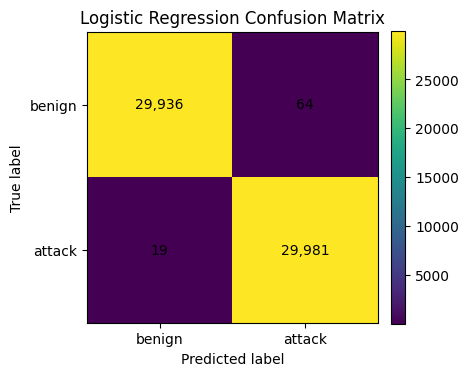

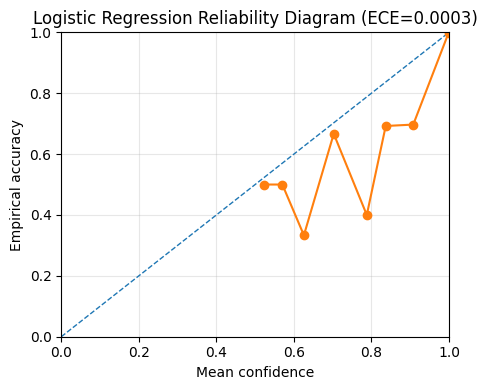


[Training]
Training samples     : 192,000
Features             : 115
Training time        : 5.818 sec

[Validation metrics]
accuracy            : 0.998479
macro_f1            : 0.998479
weighted_f1         : 0.998479
balanced_accuracy   : 0.998479
ECE                 : 0.000482
Brier score         : 0.001392

[Test metrics]
accuracy            : 0.998617
macro_f1            : 0.998617
weighted_f1         : 0.998617
balanced_accuracy   : 0.998617
ECE                 : 0.000321
Brier score         : 0.001239

[Test confusion matrix]
             pred_benign  pred_attack
true_benign        29936           64
true_attack           19        29981

[Saved]
Model                         : F:\MBZUAI UAE\16-Conference\1-UVIF-IoT-WiMob26\UVIF-IoT-WiMob2026\outputs\models\logistic_regression.joblib
Clean metrics running table    : F:\MBZUAI UAE\16-Conference\1-UVIF-IoT-WiMob26\UVIF-IoT-WiMob2026\outputs\tables\clean_performance_running.csv
Calibration running table      : F:\MBZUAI UAE\16-Confe

In [7]:
# Cell 6 - Logistic Regression baseline

from sklearn.linear_model import LogisticRegression

print("=" * 80)
print("Cell 6 | Logistic Regression Baseline")
print("=" * 80)

start_time = time.time()

logreg = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="lbfgs",
    max_iter=500,
    random_state=SEED,
    n_jobs=-1,
)

logreg.fit(X_train, y_train)

train_time = time.time() - start_time

val_proba_lr = logreg.predict_proba(X_val)
test_proba_lr = logreg.predict_proba(X_test)

val_pred_lr = np.argmax(val_proba_lr, axis=1)
test_pred_lr = np.argmax(test_proba_lr, axis=1)

val_metrics_lr = evaluate_classifier_outputs(
    model_name="Logistic Regression",
    split_name="validation",
    y_true=y_val,
    y_pred=val_pred_lr,
    y_proba=val_proba_lr,
    n_features=X_train.shape[1],
    notes="L2 logistic regression baseline",
)

test_metrics_lr = evaluate_classifier_outputs(
    model_name="Logistic Regression",
    split_name="test",
    y_true=y_test,
    y_pred=test_pred_lr,
    y_proba=test_proba_lr,
    n_features=X_train.shape[1],
    notes="L2 logistic regression baseline",
)

val_cal_lr, val_bins_lr = calibration_summary(
    model_name="Logistic Regression",
    split_name="validation",
    y_true=y_val,
    y_proba=val_proba_lr,
    n_bins=CONFIG["calibration_bins"],
)

test_cal_lr, test_bins_lr = calibration_summary(
    model_name="Logistic Regression",
    split_name="test",
    y_true=y_test,
    y_proba=test_proba_lr,
    n_bins=CONFIG["calibration_bins"],
)

val_metrics_lr["train_time_sec"] = round(train_time, 3)
test_metrics_lr["train_time_sec"] = round(train_time, 3)

clean_results.extend([val_metrics_lr, test_metrics_lr])
calibration_results.extend([val_cal_lr, test_cal_lr])

# ---------------------------------------------------------------------
# Save model and outputs
# ---------------------------------------------------------------------

logreg_model_path = MODELS_DIR / "logistic_regression.joblib"
joblib.dump(logreg, logreg_model_path)

clean_results_path = save_clean_results()

calibration_results_path = TABLES_DIR / "calibration_results_running.csv"
pd.DataFrame(calibration_results).to_csv(calibration_results_path, index=False)

val_bins_path = TABLES_DIR / "logreg_validation_calibration_bins.csv"
test_bins_path = TABLES_DIR / "logreg_test_calibration_bins.csv"
val_bins_lr.to_csv(val_bins_path, index=False)
test_bins_lr.to_csv(test_bins_path, index=False)

class_report_lr = classification_report(
    y_test,
    test_pred_lr,
    target_names=["benign", "attack"],
    output_dict=True,
    zero_division=0,
)

class_report_lr_path = TABLES_DIR / "logreg_test_classification_report.csv"
pd.DataFrame(class_report_lr).transpose().to_csv(class_report_lr_path)

test_predictions_lr = pd.DataFrame({
    "y_true": y_test,
    "y_pred": test_pred_lr,
    "p_benign": test_proba_lr[:, 0],
    "p_attack": test_proba_lr[:, 1],
    "confidence": np.max(test_proba_lr, axis=1),
    "correct": test_pred_lr == y_test,
})

test_predictions_lr_path = TABLES_DIR / "logreg_test_predictions.csv"
test_predictions_lr.to_csv(test_predictions_lr_path, index=False)

# ---------------------------------------------------------------------
# Figures
# ---------------------------------------------------------------------

cm_lr, cm_lr_png, cm_lr_pdf = plot_confusion_matrix(
    y_true=y_test,
    y_pred=test_pred_lr,
    title="Logistic Regression Confusion Matrix",
    file_stem="logreg_confusion_matrix",
)

rel_lr_png, rel_lr_pdf = plot_reliability_diagram(
    bins_df=test_bins_lr,
    title=f"Logistic Regression Reliability Diagram (ECE={test_cal_lr['ece']:.4f})",
    file_stem="logreg_reliability_diagram",
)

# ---------------------------------------------------------------------
# Console report
# ---------------------------------------------------------------------

print("\n[Training]")
print(f"Training samples     : {X_train.shape[0]:,}")
print(f"Features             : {X_train.shape[1]}")
print(f"Training time        : {train_time:.3f} sec")

print("\n[Validation metrics]")
for key in ["accuracy", "macro_f1", "weighted_f1", "balanced_accuracy"]:
    print(f"{key:20s}: {val_metrics_lr[key]:.6f}")
print(f"{'ECE':20s}: {val_cal_lr['ece']:.6f}")
print(f"{'Brier score':20s}: {val_cal_lr['brier_score']:.6f}")

print("\n[Test metrics]")
for key in ["accuracy", "macro_f1", "weighted_f1", "balanced_accuracy"]:
    print(f"{key:20s}: {test_metrics_lr[key]:.6f}")
print(f"{'ECE':20s}: {test_cal_lr['ece']:.6f}")
print(f"{'Brier score':20s}: {test_cal_lr['brier_score']:.6f}")

print("\n[Test confusion matrix]")
print(pd.DataFrame(
    cm_lr,
    index=["true_benign", "true_attack"],
    columns=["pred_benign", "pred_attack"],
).to_string())

print("\n[Saved]")
print(f"Model                         : {logreg_model_path}")
print(f"Clean metrics running table    : {clean_results_path}")
print(f"Calibration running table      : {calibration_results_path}")
print(f"Validation calibration bins     : {val_bins_path}")
print(f"Test calibration bins           : {test_bins_path}")
print(f"Classification report           : {class_report_lr_path}")
print(f"Test predictions                : {test_predictions_lr_path}")
print(f"Confusion matrix PNG/PDF        : {cm_lr_png}")
print(f"Reliability diagram PNG/PDF     : {rel_lr_png}")

print("\nCell 6 complete.")
print("=" * 80)

Cell 7 | Random Forest Baseline


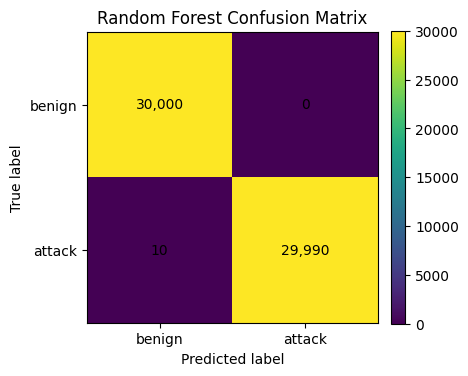

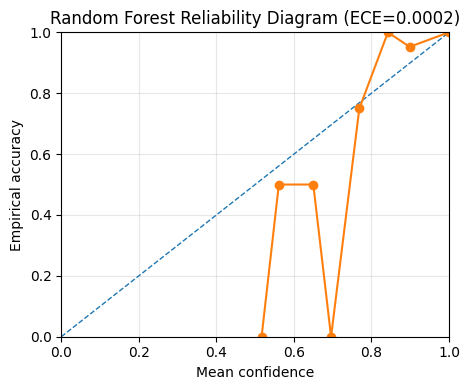

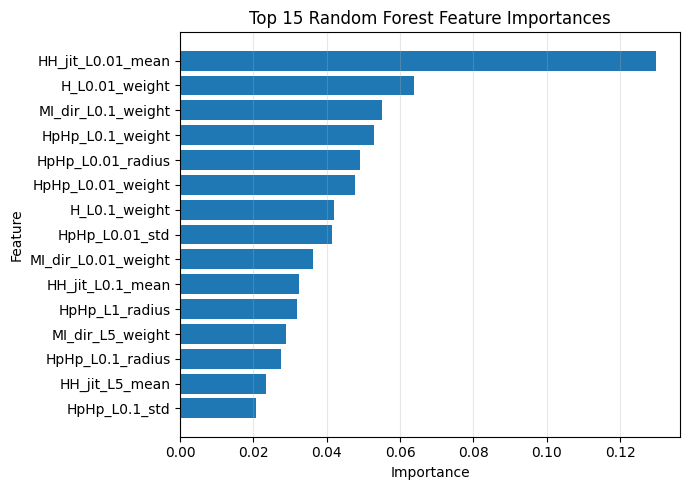


[Training]
Training samples     : 192,000
Features             : 115
Trees                : 120
Training time        : 6.736 sec

[Validation metrics]
accuracy            : 0.999729
macro_f1            : 0.999729
weighted_f1         : 0.999729
balanced_accuracy   : 0.999729
ECE                 : 0.000247
Brier score         : 0.000163

[Test metrics]
accuracy            : 0.999833
macro_f1            : 0.999833
weighted_f1         : 0.999833
balanced_accuracy   : 0.999833
ECE                 : 0.000170
Brier score         : 0.000106

[Test confusion matrix]
             pred_benign  pred_attack
true_benign        30000            0
true_attack           10        29990

[Top 15 features by Random Forest importance]
 rank             feature  importance
    1   HH_jit_L0.01_mean    0.129864
    2      H_L0.01_weight    0.063924
    3  MI_dir_L0.1_weight    0.055105
    4    HpHp_L0.1_weight    0.052794
    5   HpHp_L0.01_radius    0.049029
    6   HpHp_L0.01_weight    0.047659
    7   

In [8]:
# Cell 7 - Random Forest baseline and feature importance

from sklearn.ensemble import RandomForestClassifier

print("=" * 80)
print("Cell 7 | Random Forest Baseline")
print("=" * 80)

start_time = time.time()

rf = RandomForestClassifier(
    n_estimators=120,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    bootstrap=True,
    class_weight=None,
    n_jobs=-1,
    random_state=SEED,
)

# Tree models do not require scaling, so we use raw features.
rf.fit(X_train_raw, y_train)

train_time = time.time() - start_time

val_proba_rf = rf.predict_proba(X_val_raw)
test_proba_rf = rf.predict_proba(X_test_raw)

val_pred_rf = np.argmax(val_proba_rf, axis=1)
test_pred_rf = np.argmax(test_proba_rf, axis=1)

val_metrics_rf = evaluate_classifier_outputs(
    model_name="Random Forest",
    split_name="validation",
    y_true=y_val,
    y_pred=val_pred_rf,
    y_proba=val_proba_rf,
    n_features=X_train_raw.shape[1],
    notes="Random forest baseline on raw features",
)

test_metrics_rf = evaluate_classifier_outputs(
    model_name="Random Forest",
    split_name="test",
    y_true=y_test,
    y_pred=test_pred_rf,
    y_proba=test_proba_rf,
    n_features=X_train_raw.shape[1],
    notes="Random forest baseline on raw features",
)

val_cal_rf, val_bins_rf = calibration_summary(
    model_name="Random Forest",
    split_name="validation",
    y_true=y_val,
    y_proba=val_proba_rf,
    n_bins=CONFIG["calibration_bins"],
)

test_cal_rf, test_bins_rf = calibration_summary(
    model_name="Random Forest",
    split_name="test",
    y_true=y_test,
    y_proba=test_proba_rf,
    n_bins=CONFIG["calibration_bins"],
)

val_metrics_rf["train_time_sec"] = round(train_time, 3)
test_metrics_rf["train_time_sec"] = round(train_time, 3)

clean_results.extend([val_metrics_rf, test_metrics_rf])
calibration_results.extend([val_cal_rf, test_cal_rf])

# ---------------------------------------------------------------------
# Feature importance
# ---------------------------------------------------------------------

rf_feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

rf_feature_importance_df["rank"] = np.arange(1, len(rf_feature_importance_df) + 1)

# Keep a global list for feature-efficiency cells.
rf_ranked_features = rf_feature_importance_df["feature"].tolist()

# ---------------------------------------------------------------------
# Save model and outputs
# ---------------------------------------------------------------------

rf_model_path = MODELS_DIR / "random_forest.joblib"
joblib.dump(rf, rf_model_path)

clean_results_path = save_clean_results()

calibration_results_path = TABLES_DIR / "calibration_results_running.csv"
pd.DataFrame(calibration_results).to_csv(calibration_results_path, index=False)

val_bins_path = TABLES_DIR / "rf_validation_calibration_bins.csv"
test_bins_path = TABLES_DIR / "rf_test_calibration_bins.csv"
val_bins_rf.to_csv(val_bins_path, index=False)
test_bins_rf.to_csv(test_bins_path, index=False)

rf_importance_path = TABLES_DIR / "rf_feature_importance.csv"
rf_feature_importance_df.to_csv(rf_importance_path, index=False)

class_report_rf = classification_report(
    y_test,
    test_pred_rf,
    target_names=["benign", "attack"],
    output_dict=True,
    zero_division=0,
)

class_report_rf_path = TABLES_DIR / "rf_test_classification_report.csv"
pd.DataFrame(class_report_rf).transpose().to_csv(class_report_rf_path)

test_predictions_rf = pd.DataFrame({
    "y_true": y_test,
    "y_pred": test_pred_rf,
    "p_benign": test_proba_rf[:, 0],
    "p_attack": test_proba_rf[:, 1],
    "confidence": np.max(test_proba_rf, axis=1),
    "correct": test_pred_rf == y_test,
})

test_predictions_rf_path = TABLES_DIR / "rf_test_predictions.csv"
test_predictions_rf.to_csv(test_predictions_rf_path, index=False)

# ---------------------------------------------------------------------
# Figures
# ---------------------------------------------------------------------

cm_rf, cm_rf_png, cm_rf_pdf = plot_confusion_matrix(
    y_true=y_test,
    y_pred=test_pred_rf,
    title="Random Forest Confusion Matrix",
    file_stem="rf_confusion_matrix",
)

rel_rf_png, rel_rf_pdf = plot_reliability_diagram(
    bins_df=test_bins_rf,
    title=f"Random Forest Reliability Diagram (ECE={test_cal_rf['ece']:.4f})",
    file_stem="rf_reliability_diagram",
)

top_k = 15
top_features_df = rf_feature_importance_df.head(top_k).iloc[::-1].copy()

fig, ax = plt.subplots(figsize=(7.0, 5.0))
ax.barh(top_features_df["feature"], top_features_df["importance"])
ax.set_title(f"Top {top_k} Random Forest Feature Importances")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
ax.grid(axis="x", alpha=0.3)

fig.tight_layout()

rf_importance_png, rf_importance_pdf = save_current_figure("rf_top_feature_importance")
plt.show()

# ---------------------------------------------------------------------
# Console report
# ---------------------------------------------------------------------

print("\n[Training]")
print(f"Training samples     : {X_train_raw.shape[0]:,}")
print(f"Features             : {X_train_raw.shape[1]}")
print(f"Trees                : {rf.n_estimators}")
print(f"Training time        : {train_time:.3f} sec")

print("\n[Validation metrics]")
for key in ["accuracy", "macro_f1", "weighted_f1", "balanced_accuracy"]:
    print(f"{key:20s}: {val_metrics_rf[key]:.6f}")
print(f"{'ECE':20s}: {val_cal_rf['ece']:.6f}")
print(f"{'Brier score':20s}: {val_cal_rf['brier_score']:.6f}")

print("\n[Test metrics]")
for key in ["accuracy", "macro_f1", "weighted_f1", "balanced_accuracy"]:
    print(f"{key:20s}: {test_metrics_rf[key]:.6f}")
print(f"{'ECE':20s}: {test_cal_rf['ece']:.6f}")
print(f"{'Brier score':20s}: {test_cal_rf['brier_score']:.6f}")

print("\n[Test confusion matrix]")
print(pd.DataFrame(
    cm_rf,
    index=["true_benign", "true_attack"],
    columns=["pred_benign", "pred_attack"],
).to_string())

print("\n[Top 15 features by Random Forest importance]")
print(
    rf_feature_importance_df
    .head(15)[["rank", "feature", "importance"]]
    .to_string(index=False)
)

print("\n[Saved]")
print(f"Model                         : {rf_model_path}")
print(f"Clean metrics running table    : {clean_results_path}")
print(f"Calibration running table      : {calibration_results_path}")
print(f"Validation calibration bins     : {val_bins_path}")
print(f"Test calibration bins           : {test_bins_path}")
print(f"Feature importance table        : {rf_importance_path}")
print(f"Classification report           : {class_report_rf_path}")
print(f"Test predictions                : {test_predictions_rf_path}")
print(f"Confusion matrix PNG/PDF        : {cm_rf_png}")
print(f"Reliability diagram PNG/PDF     : {rel_rf_png}")
print(f"Feature importance PNG/PDF      : {rf_importance_png}")

print("\nCell 7 complete.")
print("=" * 80)

Cell 8 | Standard MLP Baseline
Epoch 01 | train loss 0.03321 | val loss 0.00759 | train F1 0.99407 | val F1 0.99827
Epoch 02 | train loss 0.00501 | val loss 0.00619 | train F1 0.99890 | val F1 0.99871
Epoch 03 | train loss 0.00367 | val loss 0.00492 | train F1 0.99916 | val F1 0.99912
Epoch 04 | train loss 0.00286 | val loss 0.00552 | train F1 0.99939 | val F1 0.99898
Epoch 05 | train loss 0.00283 | val loss 0.00472 | train F1 0.99936 | val F1 0.99929
Epoch 06 | train loss 0.00270 | val loss 0.00529 | train F1 0.99946 | val F1 0.99904
Epoch 07 | train loss 0.00262 | val loss 0.00445 | train F1 0.99944 | val F1 0.99915
Epoch 08 | train loss 0.00226 | val loss 0.00527 | train F1 0.99952 | val F1 0.99921
Epoch 09 | train loss 0.00221 | val loss 0.00514 | train F1 0.99956 | val F1 0.99910
Epoch 10 | train loss 0.00207 | val loss 0.00464 | train F1 0.99956 | val F1 0.99931
Epoch 11 | train loss 0.00216 | val loss 0.00449 | train F1 0.99954 | val F1 0.99917
Epoch 12 | train loss 0.00210 | va

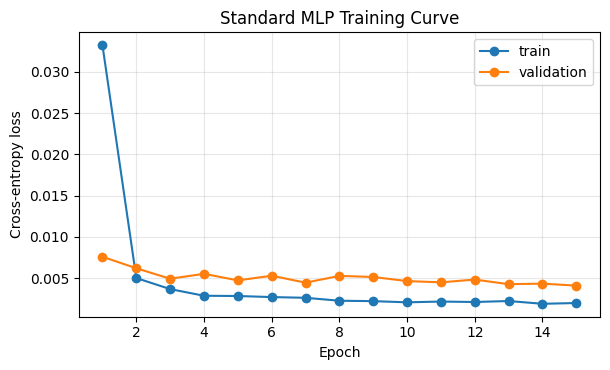

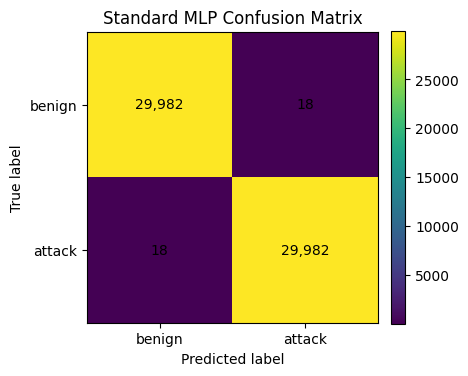

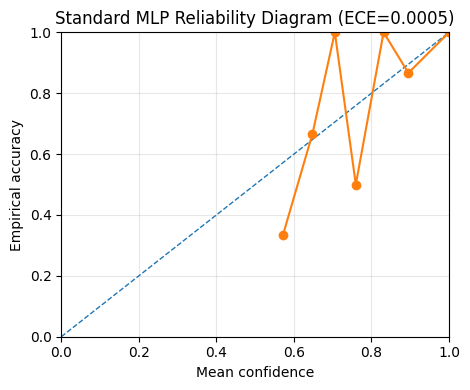


[Model]
Architecture          : input-[128, 64]-2
Dropout               : 0.2
Trainable parameters  : 23,234
Best epoch            : 10
Training time         : 79.562 sec
Device                : cuda

[Validation metrics]
accuracy            : 0.999313
macro_f1            : 0.999312
weighted_f1         : 0.999312
balanced_accuracy   : 0.999313
ECE                 : 0.000556
Brier score         : 0.000686

[Test metrics]
accuracy            : 0.999400
macro_f1            : 0.999400
weighted_f1         : 0.999400
balanced_accuracy   : 0.999400
ECE                 : 0.000524
Brier score         : 0.000547

[Test confusion matrix]
             pred_benign  pred_attack
true_benign        29982           18
true_attack           18        29982

[Test uncertainty summary]
       model split     group  n_samples  mean_confidence  mean_confidence_uncertainty  mean_entropy  mean_margin_uncertainty
Standard MLP  test incorrect         36         0.905281                     0.094719      0.1947

In [9]:
# Cell 8 - Standard MLP baseline

print("=" * 80)
print("Cell 8 | Standard MLP Baseline")
print("=" * 80)

set_seed(SEED)


# ---------------------------------------------------------------------
# Torch data loaders
# ---------------------------------------------------------------------

def make_loader(X_arr, y_arr, batch_size=512, shuffle=False):
    X_tensor = torch.tensor(X_arr, dtype=torch.float32)
    y_tensor = torch.tensor(y_arr, dtype=torch.long)

    ds = TensorDataset(X_tensor, y_tensor)

    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=CONFIG["num_workers"],
        pin_memory=CUDA_AVAILABLE,
    )


train_loader = make_loader(
    X_train,
    y_train,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
)

val_loader = make_loader(
    X_val,
    y_val,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
)

test_loader = make_loader(
    X_test,
    y_test,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
)


# ---------------------------------------------------------------------
# Model
# ---------------------------------------------------------------------

class MLPClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dims=(128, 64), dropout=0.2, num_classes=2):
        super().__init__()

        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, num_classes))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


mlp = MLPClassifier(
    input_dim=X_train.shape[1],
    hidden_dims=CONFIG["mlp_hidden_dims"],
    dropout=CONFIG["dropout"],
    num_classes=2,
).to(DEVICE)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    mlp.parameters(),
    lr=CONFIG["learning_rate"],
    weight_decay=CONFIG["weight_decay"],
)


# ---------------------------------------------------------------------
# Evaluation helpers for torch models
# ---------------------------------------------------------------------

@torch.no_grad()
def predict_torch(model, loader):
    model.eval()

    all_logits = []
    all_y = []

    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        logits = model(xb)

        all_logits.append(logits.detach().cpu())
        all_y.append(yb.detach().cpu())

    logits = torch.cat(all_logits, dim=0).numpy()
    y_true = torch.cat(all_y, dim=0).numpy()

    proba = torch.softmax(torch.tensor(logits), dim=1).numpy()
    pred = np.argmax(proba, axis=1)

    return y_true, logits, proba, pred


def run_one_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_seen = 0
    all_pred = []
    all_true = []

    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            logits = model(xb)
            loss = criterion(logits, yb)

            if is_train:
                loss.backward()
                optimizer.step()

        batch_size = yb.size(0)
        total_loss += float(loss.item()) * batch_size
        total_seen += batch_size

        pred = torch.argmax(logits.detach(), dim=1)
        all_pred.append(pred.cpu().numpy())
        all_true.append(yb.detach().cpu().numpy())

    y_epoch = np.concatenate(all_true)
    pred_epoch = np.concatenate(all_pred)

    metrics = classification_metrics(y_epoch, pred_epoch)
    avg_loss = total_loss / total_seen

    return avg_loss, metrics


# ---------------------------------------------------------------------
# Training loop
# ---------------------------------------------------------------------

best_val_macro_f1 = -1.0
best_state = None
best_epoch = 0
epochs_without_improvement = 0

history = []

start_time = time.time()

for epoch in range(1, CONFIG["max_epochs"] + 1):
    train_loss, train_metrics = run_one_epoch(
        model=mlp,
        loader=train_loader,
        optimizer=optimizer,
    )

    val_loss, val_metrics = run_one_epoch(
        model=mlp,
        loader=val_loader,
        optimizer=None,
    )

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_accuracy": train_metrics["accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "val_accuracy": val_metrics["accuracy"],
        "val_macro_f1": val_metrics["macro_f1"],
    }
    history.append(row)

    improved = val_metrics["macro_f1"] > best_val_macro_f1

    if improved:
        best_val_macro_f1 = val_metrics["macro_f1"]
        best_epoch = epoch
        best_state = {
            "model_state_dict": {k: v.detach().cpu().clone() for k, v in mlp.state_dict().items()},
            "epoch": epoch,
            "val_macro_f1": best_val_macro_f1,
            "config": CONFIG,
        }
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    print(
        f"Epoch {epoch:02d} | "
        f"train loss {train_loss:.5f} | val loss {val_loss:.5f} | "
        f"train F1 {train_metrics['macro_f1']:.5f} | val F1 {val_metrics['macro_f1']:.5f}"
    )

    if epochs_without_improvement >= CONFIG["early_stopping_patience"]:
        print(f"Early stopping at epoch {epoch}. Best epoch: {best_epoch}.")
        break

train_time = time.time() - start_time

# Restore best validation model.
mlp.load_state_dict(best_state["model_state_dict"])
mlp = mlp.to(DEVICE)


# ---------------------------------------------------------------------
# Evaluation
# ---------------------------------------------------------------------

_, val_logits_mlp, val_proba_mlp, val_pred_mlp = predict_torch(mlp, val_loader)
_, test_logits_mlp, test_proba_mlp, test_pred_mlp = predict_torch(mlp, test_loader)

val_metrics_mlp = evaluate_classifier_outputs(
    model_name="Standard MLP",
    split_name="validation",
    y_true=y_val,
    y_pred=val_pred_mlp,
    y_proba=val_proba_mlp,
    n_features=X_train.shape[1],
    notes="Two-hidden-layer MLP baseline",
)

test_metrics_mlp = evaluate_classifier_outputs(
    model_name="Standard MLP",
    split_name="test",
    y_true=y_test,
    y_pred=test_pred_mlp,
    y_proba=test_proba_mlp,
    n_features=X_train.shape[1],
    notes="Two-hidden-layer MLP baseline",
)

val_cal_mlp, val_bins_mlp = calibration_summary(
    model_name="Standard MLP",
    split_name="validation",
    y_true=y_val,
    y_proba=val_proba_mlp,
    n_bins=CONFIG["calibration_bins"],
)

test_cal_mlp, test_bins_mlp = calibration_summary(
    model_name="Standard MLP",
    split_name="test",
    y_true=y_test,
    y_proba=test_proba_mlp,
    n_bins=CONFIG["calibration_bins"],
)

val_metrics_mlp["train_time_sec"] = round(train_time, 3)
test_metrics_mlp["train_time_sec"] = round(train_time, 3)

clean_results.extend([val_metrics_mlp, test_metrics_mlp])
calibration_results.extend([val_cal_mlp, test_cal_mlp])


# ---------------------------------------------------------------------
# Save artifacts
# ---------------------------------------------------------------------

mlp_model_path = MODELS_DIR / "standard_mlp.pt"
torch.save(best_state, mlp_model_path)

history_df = pd.DataFrame(history)
history_path = TABLES_DIR / "standard_mlp_training_history.csv"
history_df.to_csv(history_path, index=False)

clean_results_path = save_clean_results()

calibration_results_path = TABLES_DIR / "calibration_results_running.csv"
pd.DataFrame(calibration_results).to_csv(calibration_results_path, index=False)

val_bins_path = TABLES_DIR / "standard_mlp_validation_calibration_bins.csv"
test_bins_path = TABLES_DIR / "standard_mlp_test_calibration_bins.csv"
val_bins_mlp.to_csv(val_bins_path, index=False)
test_bins_mlp.to_csv(test_bins_path, index=False)

class_report_mlp = classification_report(
    y_test,
    test_pred_mlp,
    target_names=["benign", "attack"],
    output_dict=True,
    zero_division=0,
)

class_report_mlp_path = TABLES_DIR / "standard_mlp_test_classification_report.csv"
pd.DataFrame(class_report_mlp).transpose().to_csv(class_report_mlp_path)

test_predictions_mlp = pd.DataFrame({
    "y_true": y_test,
    "y_pred": test_pred_mlp,
    "p_benign": test_proba_mlp[:, 0],
    "p_attack": test_proba_mlp[:, 1],
    "confidence": np.max(test_proba_mlp, axis=1),
    "correct": test_pred_mlp == y_test,
})

test_predictions_mlp_path = TABLES_DIR / "standard_mlp_test_predictions.csv"
test_predictions_mlp.to_csv(test_predictions_mlp_path, index=False)

test_uncertainty_mlp = uncertainty_summary(
    model_name="Standard MLP",
    split_name="test",
    y_true=y_test,
    y_proba=test_proba_mlp,
)

test_uncertainty_mlp_path = TABLES_DIR / "standard_mlp_test_uncertainty_summary.csv"
test_uncertainty_mlp.to_csv(test_uncertainty_mlp_path, index=False)


# ---------------------------------------------------------------------
# Figures
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(6.2, 3.8))
ax.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train")
ax.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="validation")
ax.set_title("Standard MLP Training Curve")
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-entropy loss")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()

mlp_curve_png, mlp_curve_pdf = save_current_figure("standard_mlp_training_curve")
plt.show()

cm_mlp, cm_mlp_png, cm_mlp_pdf = plot_confusion_matrix(
    y_true=y_test,
    y_pred=test_pred_mlp,
    title="Standard MLP Confusion Matrix",
    file_stem="standard_mlp_confusion_matrix",
)

rel_mlp_png, rel_mlp_pdf = plot_reliability_diagram(
    bins_df=test_bins_mlp,
    title=f"Standard MLP Reliability Diagram (ECE={test_cal_mlp['ece']:.4f})",
    file_stem="standard_mlp_reliability_diagram",
)


# ---------------------------------------------------------------------
# Console report
# ---------------------------------------------------------------------

print("\n[Model]")
print(f"Architecture          : input-{CONFIG['mlp_hidden_dims']}-2")
print(f"Dropout               : {CONFIG['dropout']}")
print(f"Trainable parameters  : {count_trainable_params(mlp):,}")
print(f"Best epoch            : {best_epoch}")
print(f"Training time         : {train_time:.3f} sec")
print(f"Device                : {DEVICE}")

print("\n[Validation metrics]")
for key in ["accuracy", "macro_f1", "weighted_f1", "balanced_accuracy"]:
    print(f"{key:20s}: {val_metrics_mlp[key]:.6f}")
print(f"{'ECE':20s}: {val_cal_mlp['ece']:.6f}")
print(f"{'Brier score':20s}: {val_cal_mlp['brier_score']:.6f}")

print("\n[Test metrics]")
for key in ["accuracy", "macro_f1", "weighted_f1", "balanced_accuracy"]:
    print(f"{key:20s}: {test_metrics_mlp[key]:.6f}")
print(f"{'ECE':20s}: {test_cal_mlp['ece']:.6f}")
print(f"{'Brier score':20s}: {test_cal_mlp['brier_score']:.6f}")

print("\n[Test confusion matrix]")
print(pd.DataFrame(
    cm_mlp,
    index=["true_benign", "true_attack"],
    columns=["pred_benign", "pred_attack"],
).to_string())

print("\n[Test uncertainty summary]")
print(test_uncertainty_mlp.to_string(index=False))

print("\n[Saved]")
print(f"Model                         : {mlp_model_path}")
print(f"Training history              : {history_path}")
print(f"Clean metrics running table    : {clean_results_path}")
print(f"Calibration running table      : {calibration_results_path}")
print(f"Validation calibration bins     : {val_bins_path}")
print(f"Test calibration bins           : {test_bins_path}")
print(f"Classification report           : {class_report_mlp_path}")
print(f"Test predictions                : {test_predictions_mlp_path}")
print(f"Uncertainty summary             : {test_uncertainty_mlp_path}")
print(f"Training curve PNG/PDF          : {mlp_curve_png}")
print(f"Confusion matrix PNG/PDF        : {cm_mlp_png}")
print(f"Reliability diagram PNG/PDF     : {rel_mlp_png}")

print("\nCell 8 complete.")
print("=" * 80)

Cell 9 | UVIF-IoT Calibration and Uncertainty


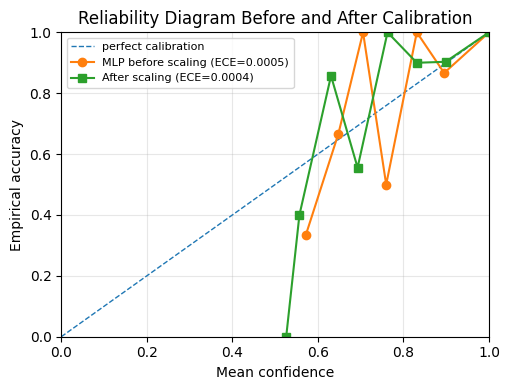

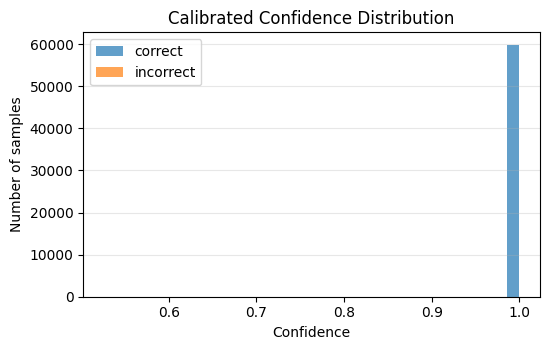

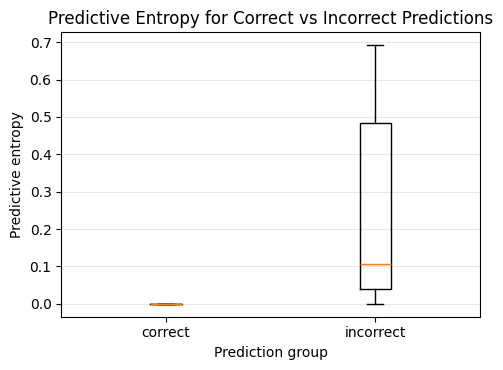


[Temperature scaling]
Fitted temperature      : 1.392007

[Validation calibration]
ECE before             : 0.000556
ECE after              : 0.000177
Brier before           : 0.000686
Brier after            : 0.000692

[Test calibration]
ECE before             : 0.000524
ECE after              : 0.000351
Brier before           : 0.000547
Brier after            : 0.000558

[Test clean metrics after calibration]
accuracy            : 0.999400
macro_f1            : 0.999400
weighted_f1         : 0.999400
balanced_accuracy   : 0.999400

[Test uncertainty summary after calibration]
                  model split     group  n_samples  mean_confidence  mean_confidence_uncertainty  mean_entropy  mean_margin_uncertainty
UVIF-IoT-Calibrated MLP  test incorrect         36         0.881460                     0.118540      0.248635                  0.23708
UVIF-IoT-Calibrated MLP  test   correct      59964         0.999205                     0.000795      0.003973                  0.00159

[Save

In [10]:
# Cell 9 - UVIF-IoT calibration and uncertainty module

print("=" * 80)
print("Cell 9 | UVIF-IoT Calibration and Uncertainty")
print("=" * 80)

set_seed(SEED)


# ---------------------------------------------------------------------
# Temperature scaling fitted on validation logits
# ---------------------------------------------------------------------

class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.log_temperature = nn.Parameter(torch.zeros(1))

    def forward(self, logits):
        temperature = torch.exp(self.log_temperature)
        return logits / temperature

    @property
    def temperature(self):
        return float(torch.exp(self.log_temperature).detach().cpu().item())


def fit_temperature(logits_np, labels_np, max_iter=100):
    logits = torch.tensor(logits_np, dtype=torch.float32)
    labels = torch.tensor(labels_np, dtype=torch.long)

    scaler_module = TemperatureScaler()
    optimizer = torch.optim.LBFGS(
        scaler_module.parameters(),
        lr=0.05,
        max_iter=max_iter,
        line_search_fn="strong_wolfe",
    )

    criterion_nll = nn.CrossEntropyLoss()

    def closure():
        optimizer.zero_grad()
        scaled_logits = scaler_module(logits)
        loss = criterion_nll(scaled_logits, labels)
        loss.backward()
        return loss

    optimizer.step(closure)

    return scaler_module


def softmax_from_logits(logits_np):
    logits = torch.tensor(logits_np, dtype=torch.float32)
    return torch.softmax(logits, dim=1).numpy()


temperature_model = fit_temperature(
    logits_np=val_logits_mlp,
    labels_np=y_val,
    max_iter=100,
)

temperature_value = temperature_model.temperature

with torch.no_grad():
    val_logits_cal = temperature_model(torch.tensor(val_logits_mlp, dtype=torch.float32)).numpy()
    test_logits_cal = temperature_model(torch.tensor(test_logits_mlp, dtype=torch.float32)).numpy()

val_proba_cal = softmax_from_logits(val_logits_cal)
test_proba_cal = softmax_from_logits(test_logits_cal)

val_pred_cal = np.argmax(val_proba_cal, axis=1)
test_pred_cal = np.argmax(test_proba_cal, axis=1)


# ---------------------------------------------------------------------
# Metrics and calibration
# ---------------------------------------------------------------------

val_metrics_cal = evaluate_classifier_outputs(
    model_name="UVIF-IoT-Calibrated MLP",
    split_name="validation",
    y_true=y_val,
    y_pred=val_pred_cal,
    y_proba=val_proba_cal,
    n_features=X_train.shape[1],
    notes=f"MLP with temperature scaling, T={temperature_value:.4f}",
)

test_metrics_cal = evaluate_classifier_outputs(
    model_name="UVIF-IoT-Calibrated MLP",
    split_name="test",
    y_true=y_test,
    y_pred=test_pred_cal,
    y_proba=test_proba_cal,
    n_features=X_train.shape[1],
    notes=f"MLP with temperature scaling, T={temperature_value:.4f}",
)

val_cal_temp, val_bins_temp = calibration_summary(
    model_name="UVIF-IoT-Calibrated MLP",
    split_name="validation",
    y_true=y_val,
    y_proba=val_proba_cal,
    n_bins=CONFIG["calibration_bins"],
)

test_cal_temp, test_bins_temp = calibration_summary(
    model_name="UVIF-IoT-Calibrated MLP",
    split_name="test",
    y_true=y_test,
    y_proba=test_proba_cal,
    n_bins=CONFIG["calibration_bins"],
)

clean_results.extend([val_metrics_cal, test_metrics_cal])
calibration_results.extend([val_cal_temp, test_cal_temp])

uncertainty_test_cal_df = uncertainty_frame(y_test, test_proba_cal)

uncertainty_summary_cal = uncertainty_summary(
    model_name="UVIF-IoT-Calibrated MLP",
    split_name="test",
    y_true=y_test,
    y_proba=test_proba_cal,
)


# ---------------------------------------------------------------------
# Save outputs
# ---------------------------------------------------------------------

temperature_report = {
    "model": "UVIF-IoT-Calibrated MLP",
    "base_model": "Standard MLP",
    "temperature": temperature_value,
    "validation_ece_before": float(val_cal_mlp["ece"]),
    "validation_ece_after": float(val_cal_temp["ece"]),
    "test_ece_before": float(test_cal_mlp["ece"]),
    "test_ece_after": float(test_cal_temp["ece"]),
    "validation_brier_before": float(val_cal_mlp["brier_score"]),
    "validation_brier_after": float(val_cal_temp["brier_score"]),
    "test_brier_before": float(test_cal_mlp["brier_score"]),
    "test_brier_after": float(test_cal_temp["brier_score"]),
}

temperature_report_path = LOGS_DIR / "temperature_scaling_report.json"
with open(temperature_report_path, "w", encoding="utf-8") as f:
    json.dump(temperature_report, f, indent=4)

temperature_model_path = MODELS_DIR / "temperature_scaler.pt"
torch.save(
    {
        "temperature": temperature_value,
        "state_dict": temperature_model.state_dict(),
        "base_model": "standard_mlp.pt",
    },
    temperature_model_path,
)

clean_results_path = save_clean_results()

calibration_results_path = TABLES_DIR / "calibration_results_running.csv"
pd.DataFrame(calibration_results).to_csv(calibration_results_path, index=False)

val_bins_temp_path = TABLES_DIR / "uvif_calibrated_mlp_validation_calibration_bins.csv"
test_bins_temp_path = TABLES_DIR / "uvif_calibrated_mlp_test_calibration_bins.csv"
val_bins_temp.to_csv(val_bins_temp_path, index=False)
test_bins_temp.to_csv(test_bins_temp_path, index=False)

test_predictions_cal = pd.DataFrame({
    "y_true": y_test,
    "y_pred": test_pred_cal,
    "p_benign": test_proba_cal[:, 0],
    "p_attack": test_proba_cal[:, 1],
    "confidence": np.max(test_proba_cal, axis=1),
    "correct": test_pred_cal == y_test,
    "entropy": predictive_entropy(test_proba_cal),
    "confidence_uncertainty": 1.0 - np.max(test_proba_cal, axis=1),
    "margin_uncertainty": margin_uncertainty(test_proba_cal),
})

test_predictions_cal_path = TABLES_DIR / "uvif_calibrated_mlp_test_predictions.csv"
test_predictions_cal.to_csv(test_predictions_cal_path, index=False)

uncertainty_summary_cal_path = TABLES_DIR / "uvif_calibrated_mlp_test_uncertainty_summary.csv"
uncertainty_summary_cal.to_csv(uncertainty_summary_cal_path, index=False)


# ---------------------------------------------------------------------
# Figures
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(5.2, 4.0))

base_bins = test_bins_mlp.dropna(subset=["accuracy", "confidence"])
cal_bins = test_bins_temp.dropna(subset=["accuracy", "confidence"])

ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="perfect calibration")
ax.plot(
    base_bins["confidence"],
    base_bins["accuracy"],
    marker="o",
    label=f"MLP before scaling (ECE={test_cal_mlp['ece']:.4f})",
)
ax.plot(
    cal_bins["confidence"],
    cal_bins["accuracy"],
    marker="s",
    label=f"After scaling (ECE={test_cal_temp['ece']:.4f})",
)

ax.set_title("Reliability Diagram Before and After Calibration")
ax.set_xlabel("Mean confidence")
ax.set_ylabel("Empirical accuracy")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

fig.tight_layout()
calibration_comparison_png, calibration_comparison_pdf = save_current_figure(
    "uvif_calibration_reliability_comparison"
)
plt.show()


fig, ax = plt.subplots(figsize=(5.6, 3.6))

correct_conf = uncertainty_test_cal_df.loc[uncertainty_test_cal_df["correct"], "confidence"]
wrong_conf = uncertainty_test_cal_df.loc[~uncertainty_test_cal_df["correct"], "confidence"]

ax.hist(correct_conf, bins=30, alpha=0.7, label="correct")
ax.hist(wrong_conf, bins=30, alpha=0.7, label="incorrect")

ax.set_title("Calibrated Confidence Distribution")
ax.set_xlabel("Confidence")
ax.set_ylabel("Number of samples")
ax.grid(axis="y", alpha=0.3)
ax.legend()

fig.tight_layout()
confidence_hist_png, confidence_hist_pdf = save_current_figure(
    "uvif_calibrated_confidence_histogram"
)
plt.show()


fig, ax = plt.subplots(figsize=(5.0, 3.8))

box_data = [
    uncertainty_test_cal_df.loc[uncertainty_test_cal_df["correct"], "entropy"],
    uncertainty_test_cal_df.loc[~uncertainty_test_cal_df["correct"], "entropy"],
]

ax.boxplot(box_data, labels=["correct", "incorrect"], showfliers=False)
ax.set_title("Predictive Entropy for Correct vs Incorrect Predictions")
ax.set_xlabel("Prediction group")
ax.set_ylabel("Predictive entropy")
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()
entropy_box_png, entropy_box_pdf = save_current_figure(
    "uvif_entropy_correct_vs_incorrect"
)
plt.show()


# ---------------------------------------------------------------------
# Console report
# ---------------------------------------------------------------------

print("\n[Temperature scaling]")
print(f"Fitted temperature      : {temperature_value:.6f}")

print("\n[Validation calibration]")
print(f"ECE before             : {val_cal_mlp['ece']:.6f}")
print(f"ECE after              : {val_cal_temp['ece']:.6f}")
print(f"Brier before           : {val_cal_mlp['brier_score']:.6f}")
print(f"Brier after            : {val_cal_temp['brier_score']:.6f}")

print("\n[Test calibration]")
print(f"ECE before             : {test_cal_mlp['ece']:.6f}")
print(f"ECE after              : {test_cal_temp['ece']:.6f}")
print(f"Brier before           : {test_cal_mlp['brier_score']:.6f}")
print(f"Brier after            : {test_cal_temp['brier_score']:.6f}")

print("\n[Test clean metrics after calibration]")
for key in ["accuracy", "macro_f1", "weighted_f1", "balanced_accuracy"]:
    print(f"{key:20s}: {test_metrics_cal[key]:.6f}")

print("\n[Test uncertainty summary after calibration]")
print(uncertainty_summary_cal.to_string(index=False))

print("\n[Saved]")
print(f"Temperature report              : {temperature_report_path}")
print(f"Temperature scaler              : {temperature_model_path}")
print(f"Clean metrics running table     : {clean_results_path}")
print(f"Calibration running table       : {calibration_results_path}")
print(f"Validation calibration bins      : {val_bins_temp_path}")
print(f"Test calibration bins            : {test_bins_temp_path}")
print(f"Test predictions                 : {test_predictions_cal_path}")
print(f"Uncertainty summary              : {uncertainty_summary_cal_path}")
print(f"Reliability comparison PNG/PDF   : {calibration_comparison_png}")
print(f"Confidence histogram PNG/PDF     : {confidence_hist_png}")
print(f"Entropy boxplot PNG/PDF          : {entropy_box_png}")

print("\nCell 9 complete.")
print("=" * 80)

Cell 10 | FGSM Robustness Evaluation


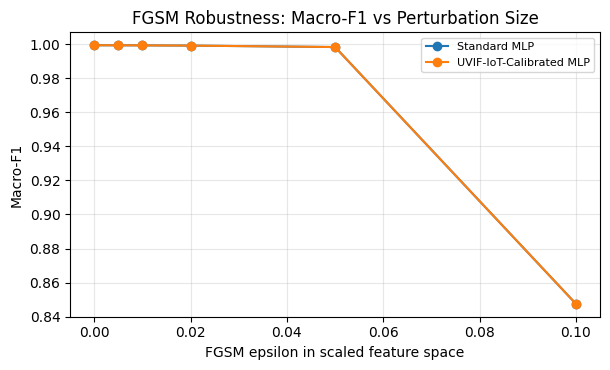

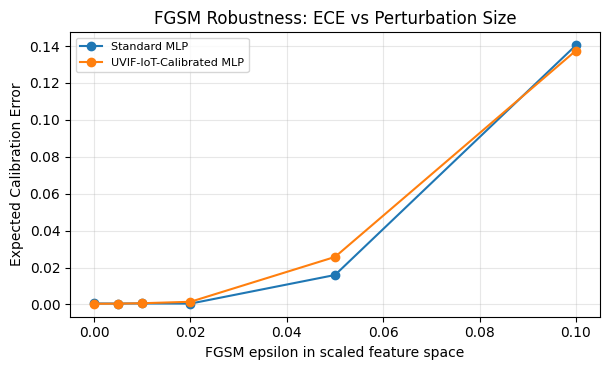

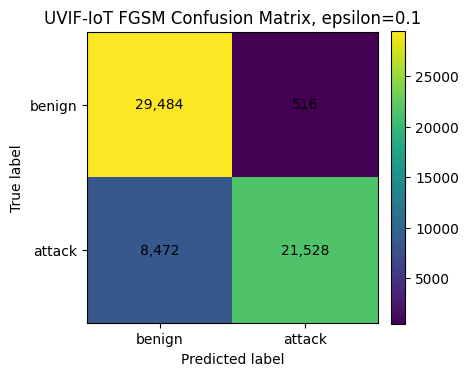


[FGSM setup]
Evaluated epsilons        : [0.0, 0.005, 0.01, 0.02, 0.05, 0.1]
Attack space              : scaled feature space
Clamping bounds           : per-feature train min/max after scaling
Test samples              : 60,000
Total FGSM eval time      : 12.338 sec

[FGSM robustness results]
                  model  epsilon  accuracy  macro_f1  balanced_accuracy      ece  macro_f1_drop_from_clean
           Standard MLP    0.000  0.999400  0.999400           0.999400 0.000524                  0.000000
           Standard MLP    0.005  0.999383  0.999383           0.999383 0.000486                  0.000017
           Standard MLP    0.010  0.999333  0.999333           0.999333 0.000532                  0.000067
           Standard MLP    0.020  0.999200  0.999200           0.999200 0.000457                  0.000200
           Standard MLP    0.050  0.998350  0.998350           0.998350 0.015960                  0.001050
           Standard MLP    0.100  0.850200  0.847519          

In [11]:
# Cell 10 - FGSM adversarial robustness evaluation

print("=" * 80)
print("Cell 10 | FGSM Robustness Evaluation")
print("=" * 80)

set_seed(SEED)

# Use the configured epsilons and add 0.0 as the clean reference.
FGSM_EPSILONS = [0.0] + list(CONFIG["fgsm_epsilons"])

# For the pilot pipeline, include two additional stress-test levels.
# These help us see whether the model degrades smoothly under larger perturbations.
for extra_eps in [0.05, 0.10]:
    if extra_eps not in FGSM_EPSILONS:
        FGSM_EPSILONS.append(extra_eps)

FGSM_EPSILONS = sorted(FGSM_EPSILONS)

x_min_tensor = torch.tensor(X_train_min, dtype=torch.float32, device=DEVICE).view(1, -1)
x_max_tensor = torch.tensor(X_train_max, dtype=torch.float32, device=DEVICE).view(1, -1)


def fgsm_batch(model, xb, yb, epsilon):
    if epsilon == 0:
        return xb.detach()

    model.eval()

    x_adv = xb.detach().clone()
    x_adv.requires_grad_(True)

    logits = model(x_adv)
    loss = F.cross_entropy(logits, yb)

    grad = torch.autograd.grad(loss, x_adv)[0]

    x_adv = x_adv + epsilon * grad.sign()
    x_adv = torch.max(torch.min(x_adv, x_max_tensor), x_min_tensor)

    return x_adv.detach()


def evaluate_fgsm(model, X_np, y_np, epsilons, temperature=None, batch_size=512):
    model.eval()

    rows = []
    predictions_by_eps = {}

    dataset = TensorDataset(
        torch.tensor(X_np, dtype=torch.float32),
        torch.tensor(y_np, dtype=torch.long),
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=CONFIG["num_workers"],
        pin_memory=CUDA_AVAILABLE,
    )

    for eps in epsilons:
        all_logits = []
        all_y = []

        start_time = time.time()

        for xb, yb in loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)

            x_adv = fgsm_batch(model, xb, yb, epsilon=eps)

            with torch.no_grad():
                logits = model(x_adv)

            all_logits.append(logits.detach().cpu())
            all_y.append(yb.detach().cpu())

        logits_np = torch.cat(all_logits, dim=0).numpy()
        y_true_np = torch.cat(all_y, dim=0).numpy()

        if temperature is not None:
            logits_for_proba = logits_np / float(temperature)
        else:
            logits_for_proba = logits_np

        proba_np = softmax_from_logits(logits_for_proba)
        pred_np = np.argmax(proba_np, axis=1)

        metrics = classification_metrics(y_true_np, pred_np)
        cal_row, bins_df = calibration_summary(
            model_name="tmp",
            split_name="fgsm_test",
            y_true=y_true_np,
            y_proba=proba_np,
            n_bins=CONFIG["calibration_bins"],
        )

        elapsed = time.time() - start_time

        row = {
            "epsilon": float(eps),
            "n_samples": int(len(y_true_np)),
            "accuracy": metrics["accuracy"],
            "macro_f1": metrics["macro_f1"],
            "weighted_f1": metrics["weighted_f1"],
            "balanced_accuracy": metrics["balanced_accuracy"],
            "ece": cal_row["ece"],
            "brier_score": cal_row["brier_score"],
            "mean_confidence": cal_row["mean_confidence"],
            "eval_time_sec": round(elapsed, 3),
        }

        rows.append(row)

        predictions_by_eps[float(eps)] = {
            "y_true": y_true_np,
            "y_pred": pred_np,
            "proba": proba_np,
            "logits": logits_np,
            "bins": bins_df,
        }

    return pd.DataFrame(rows), predictions_by_eps


start_time = time.time()

fgsm_mlp_df, fgsm_mlp_preds = evaluate_fgsm(
    model=mlp,
    X_np=X_test,
    y_np=y_test,
    epsilons=FGSM_EPSILONS,
    temperature=None,
    batch_size=CONFIG["batch_size"],
)

fgsm_mlp_df.insert(0, "model", "Standard MLP")

fgsm_uvif_df, fgsm_uvif_preds = evaluate_fgsm(
    model=mlp,
    X_np=X_test,
    y_np=y_test,
    epsilons=FGSM_EPSILONS,
    temperature=temperature_value,
    batch_size=CONFIG["batch_size"],
)

fgsm_uvif_df.insert(0, "model", "UVIF-IoT-Calibrated MLP")

fgsm_eval_time = time.time() - start_time

fgsm_results_df = pd.concat([fgsm_mlp_df, fgsm_uvif_df], axis=0, ignore_index=True)

# Add clean-to-attack drops relative to epsilon 0 for each model.
drop_rows = []

for model_name, group in fgsm_results_df.groupby("model"):
    clean_macro_f1 = float(group.loc[group["epsilon"] == 0.0, "macro_f1"].iloc[0])
    clean_accuracy = float(group.loc[group["epsilon"] == 0.0, "accuracy"].iloc[0])

    for _, row in group.iterrows():
        row_dict = row.to_dict()
        row_dict["macro_f1_drop_from_clean"] = clean_macro_f1 - float(row["macro_f1"])
        row_dict["accuracy_drop_from_clean"] = clean_accuracy - float(row["accuracy"])
        drop_rows.append(row_dict)

fgsm_results_df = pd.DataFrame(drop_rows)

robustness_results.extend(fgsm_results_df.to_dict(orient="records"))

fgsm_results_path = TABLES_DIR / "fgsm_robustness_results.csv"
fgsm_results_df.to_csv(fgsm_results_path, index=False)

robustness_running_path = TABLES_DIR / "robustness_results_running.csv"
pd.DataFrame(robustness_results).to_csv(robustness_running_path, index=False)


# ---------------------------------------------------------------------
# Save prediction table for the strongest perturbation
# ---------------------------------------------------------------------

max_eps = max(FGSM_EPSILONS)
max_eps_preds = fgsm_uvif_preds[float(max_eps)]

fgsm_max_predictions_df = pd.DataFrame({
    "y_true": max_eps_preds["y_true"],
    "y_pred": max_eps_preds["y_pred"],
    "p_benign": max_eps_preds["proba"][:, 0],
    "p_attack": max_eps_preds["proba"][:, 1],
    "confidence": np.max(max_eps_preds["proba"], axis=1),
    "correct": max_eps_preds["y_true"] == max_eps_preds["y_pred"],
    "epsilon": float(max_eps),
})

fgsm_max_predictions_path = TABLES_DIR / "uvif_fgsm_max_epsilon_predictions.csv"
fgsm_max_predictions_df.to_csv(fgsm_max_predictions_path, index=False)


# ---------------------------------------------------------------------
# Figures
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(6.2, 3.8))

for model_name, group in fgsm_results_df.groupby("model"):
    group = group.sort_values("epsilon")
    ax.plot(group["epsilon"], group["macro_f1"], marker="o", label=model_name)

ax.set_title("FGSM Robustness: Macro-F1 vs Perturbation Size")
ax.set_xlabel("FGSM epsilon in scaled feature space")
ax.set_ylabel("Macro-F1")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

fig.tight_layout()
fgsm_macro_png, fgsm_macro_pdf = save_current_figure("fgsm_macro_f1_vs_epsilon")
plt.show()


fig, ax = plt.subplots(figsize=(6.2, 3.8))

for model_name, group in fgsm_results_df.groupby("model"):
    group = group.sort_values("epsilon")
    ax.plot(group["epsilon"], group["ece"], marker="o", label=model_name)

ax.set_title("FGSM Robustness: ECE vs Perturbation Size")
ax.set_xlabel("FGSM epsilon in scaled feature space")
ax.set_ylabel("Expected Calibration Error")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

fig.tight_layout()
fgsm_ece_png, fgsm_ece_pdf = save_current_figure("fgsm_ece_vs_epsilon")
plt.show()


cm_fgsm, cm_fgsm_png, cm_fgsm_pdf = plot_confusion_matrix(
    y_true=max_eps_preds["y_true"],
    y_pred=max_eps_preds["y_pred"],
    title=f"UVIF-IoT FGSM Confusion Matrix, epsilon={max_eps}",
    file_stem="uvif_fgsm_max_epsilon_confusion_matrix",
)


# ---------------------------------------------------------------------
# Console report
# ---------------------------------------------------------------------

print("\n[FGSM setup]")
print(f"Evaluated epsilons        : {FGSM_EPSILONS}")
print(f"Attack space              : scaled feature space")
print(f"Clamping bounds           : per-feature train min/max after scaling")
print(f"Test samples              : {len(y_test):,}")
print(f"Total FGSM eval time      : {fgsm_eval_time:.3f} sec")

print("\n[FGSM robustness results]")
display_cols = [
    "model",
    "epsilon",
    "accuracy",
    "macro_f1",
    "balanced_accuracy",
    "ece",
    "macro_f1_drop_from_clean",
]
print(fgsm_results_df[display_cols].to_string(index=False))

print(f"\n[Strongest epsilon confusion matrix: epsilon={max_eps}]")
print(pd.DataFrame(
    cm_fgsm,
    index=["true_benign", "true_attack"],
    columns=["pred_benign", "pred_attack"],
).to_string())

print("\n[Saved]")
print(f"FGSM robustness table          : {fgsm_results_path}")
print(f"Robustness running table       : {robustness_running_path}")
print(f"Max-epsilon predictions        : {fgsm_max_predictions_path}")
print(f"Macro-F1 plot PNG/PDF          : {fgsm_macro_png}")
print(f"ECE plot PNG/PDF               : {fgsm_ece_png}")
print(f"Max-epsilon confusion PNG/PDF  : {cm_fgsm_png}")

print("\nCell 10 complete.")
print("=" * 80)

Cell 11 | UVIF-IoT Feature-Efficiency Experiment

[Feature ranking]
Ranking source        : Random Forest feature importance from Cell 7
Total features        : 115
Budgets evaluated     : [10, 20, 30, 50, 'all']
Max epochs per budget : 15
Early stopping patience: 3
Budget  10 | features  10 | test Macro-F1 0.998450 | ECE 0.000092 | reduction 91.3% | time 31.0s
Budget  20 | features  20 | test Macro-F1 0.999567 | ECE 0.000313 | reduction 82.6% | time 42.3s
Budget  30 | features  30 | test Macro-F1 0.999517 | ECE 0.000334 | reduction 73.9% | time 33.7s
Budget  50 | features  50 | test Macro-F1 0.999533 | ECE 0.000418 | reduction 56.5% | time 53.0s
Budget all | features 115 | test Macro-F1 0.999400 | ECE 0.000351 | reduction 0.0% | time 0.1s


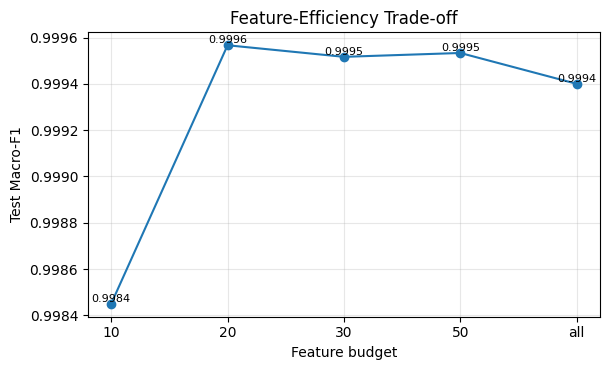

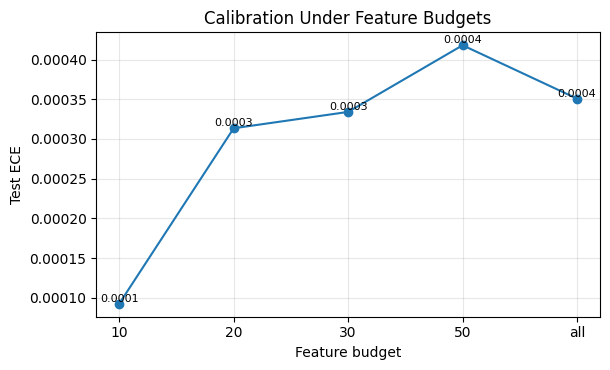

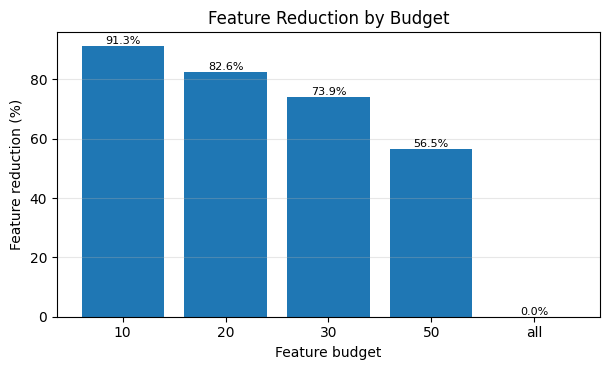

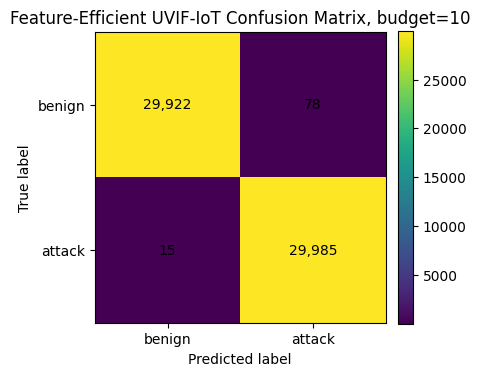


[Feature-efficiency results]
feature_budget  n_features  feature_reduction_pct  trainable_parameters  test_accuracy  test_macro_f1  test_balanced_accuracy  test_ece  temperature  train_time_sec
            10          10              91.304348                  9794       0.998450       0.998450                0.998450  0.000092     1.078322          29.602
            20          20              82.608696                 11074       0.999567       0.999567                0.999567  0.000313     0.871346          40.558
            30          30              73.913043                 12354       0.999517       0.999517                0.999517  0.000334     1.000000          32.132
            50          50              56.521739                 14914       0.999533       0.999533                0.999533  0.000418     0.987061          51.588
           all         115               0.000000                 23234       0.999400       0.999400                0.999400  0.000351     1.392

In [12]:
# Cell 11 - Feature-efficiency experiment

print("=" * 80)
print("Cell 11 | UVIF-IoT Feature-Efficiency Experiment")
print("=" * 80)

set_seed(SEED)

feature_to_idx = {name: i for i, name in enumerate(feature_names)}

budgets = CONFIG["feature_budgets"]
budgets = [b for b in budgets if b != "all"] + ["all"]

feature_budget_rows = []
feature_budget_models = {}
feature_budget_predictions = {}

# Keep pilot runtime controlled. The full run can use CONFIG["max_epochs"] later.
feature_epochs = min(CONFIG["max_epochs"], 15)
feature_patience = 3

print("\n[Feature ranking]")
print("Ranking source        : Random Forest feature importance from Cell 7")
print(f"Total features        : {len(feature_names)}")
print(f"Budgets evaluated     : {budgets}")
print(f"Max epochs per budget : {feature_epochs}")
print(f"Early stopping patience: {feature_patience}")


def train_small_mlp_for_budget(X_tr, y_tr, X_va, y_va, input_dim, seed_offset=0):
    set_seed(SEED + seed_offset)

    train_dl = make_loader(
        X_tr,
        y_tr,
        batch_size=CONFIG["batch_size"],
        shuffle=True,
    )

    val_dl = make_loader(
        X_va,
        y_va,
        batch_size=CONFIG["batch_size"],
        shuffle=False,
    )

    model = MLPClassifier(
        input_dim=input_dim,
        hidden_dims=CONFIG["mlp_hidden_dims"],
        dropout=CONFIG["dropout"],
        num_classes=2,
    ).to(DEVICE)

    opt = torch.optim.AdamW(
        model.parameters(),
        lr=CONFIG["learning_rate"],
        weight_decay=CONFIG["weight_decay"],
    )

    best_f1 = -1.0
    best_state_local = None
    best_epoch_local = 0
    stale = 0
    hist = []

    for epoch in range(1, feature_epochs + 1):
        tr_loss, tr_metrics = run_one_epoch(model, train_dl, optimizer=opt)
        va_loss, va_metrics = run_one_epoch(model, val_dl, optimizer=None)

        hist.append({
            "epoch": epoch,
            "train_loss": tr_loss,
            "val_loss": va_loss,
            "train_macro_f1": tr_metrics["macro_f1"],
            "val_macro_f1": va_metrics["macro_f1"],
        })

        if va_metrics["macro_f1"] > best_f1:
            best_f1 = va_metrics["macro_f1"]
            best_epoch_local = epoch
            best_state_local = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            stale = 0
        else:
            stale += 1

        if stale >= feature_patience:
            break

    model.load_state_dict(best_state_local)
    model = model.to(DEVICE)

    return model, pd.DataFrame(hist), best_epoch_local, best_f1


start_time_all = time.time()

for budget in budgets:
    budget_start = time.time()

    if budget == "all":
        selected_features = list(feature_names)
        selected_idx = list(range(len(feature_names)))

        # Reuse the calibrated full MLP from previous cells.
        model_name = "UVIF-IoT-FE-all"
        n_selected = len(selected_features)
        reduction_pct = 0.0

        val_pred = val_pred_cal
        test_pred = test_pred_cal
        val_proba = val_proba_cal
        test_proba = test_proba_cal

        val_metrics = evaluate_classifier_outputs(
            model_name=model_name,
            split_name="validation",
            y_true=y_val,
            y_pred=val_pred,
            y_proba=val_proba,
            n_features=n_selected,
            notes="Full calibrated MLP, reused from Cell 9",
        )

        test_metrics = evaluate_classifier_outputs(
            model_name=model_name,
            split_name="test",
            y_true=y_test,
            y_pred=test_pred,
            y_proba=test_proba,
            n_features=n_selected,
            notes="Full calibrated MLP, reused from Cell 9",
        )

        val_cal, _ = calibration_summary(
            model_name=model_name,
            split_name="validation",
            y_true=y_val,
            y_proba=val_proba,
            n_bins=CONFIG["calibration_bins"],
        )

        test_cal, _ = calibration_summary(
            model_name=model_name,
            split_name="test",
            y_true=y_test,
            y_proba=test_proba,
            n_bins=CONFIG["calibration_bins"],
        )

        train_time = 0.0
        best_epoch_budget = best_epoch
        params = count_trainable_params(mlp)

        feature_budget_models[budget] = {
            "model_name": model_name,
            "model": mlp,
            "temperature": temperature_value,
            "selected_features": selected_features,
            "selected_idx": selected_idx,
        }

    else:
        selected_features = rf_ranked_features[:int(budget)]
        selected_idx = [feature_to_idx[f] for f in selected_features]

        X_train_k = X_train[:, selected_idx]
        X_val_k = X_val[:, selected_idx]
        X_test_k = X_test[:, selected_idx]

        model_name = f"UVIF-IoT-FE-{budget}"
        n_selected = len(selected_features)
        reduction_pct = 100.0 * (1.0 - n_selected / len(feature_names))

        train_start = time.time()

        model_k, hist_k, best_epoch_budget, best_val_f1_budget = train_small_mlp_for_budget(
            X_tr=X_train_k,
            y_tr=y_train,
            X_va=X_val_k,
            y_va=y_val,
            input_dim=n_selected,
            seed_offset=int(budget),
        )

        train_time = time.time() - train_start

        val_loader_k = make_loader(
            X_val_k,
            y_val,
            batch_size=CONFIG["batch_size"],
            shuffle=False,
        )

        test_loader_k = make_loader(
            X_test_k,
            y_test,
            batch_size=CONFIG["batch_size"],
            shuffle=False,
        )

        _, val_logits_k, val_proba_uncal_k, val_pred_uncal_k = predict_torch(model_k, val_loader_k)
        _, test_logits_k, test_proba_uncal_k, test_pred_uncal_k = predict_torch(model_k, test_loader_k)

        temp_k = fit_temperature(
            logits_np=val_logits_k,
            labels_np=y_val,
            max_iter=100,
        )

        T_k = temp_k.temperature

        val_proba = softmax_from_logits(val_logits_k / T_k)
        test_proba = softmax_from_logits(test_logits_k / T_k)

        val_pred = np.argmax(val_proba, axis=1)
        test_pred = np.argmax(test_proba, axis=1)

        val_metrics = evaluate_classifier_outputs(
            model_name=model_name,
            split_name="validation",
            y_true=y_val,
            y_pred=val_pred,
            y_proba=val_proba,
            n_features=n_selected,
            notes=f"Top-{budget} RF-ranked features, calibrated MLP",
        )

        test_metrics = evaluate_classifier_outputs(
            model_name=model_name,
            split_name="test",
            y_true=y_test,
            y_pred=test_pred,
            y_proba=test_proba,
            n_features=n_selected,
            notes=f"Top-{budget} RF-ranked features, calibrated MLP",
        )

        val_cal, _ = calibration_summary(
            model_name=model_name,
            split_name="validation",
            y_true=y_val,
            y_proba=val_proba,
            n_bins=CONFIG["calibration_bins"],
        )

        test_cal, _ = calibration_summary(
            model_name=model_name,
            split_name="test",
            y_true=y_test,
            y_proba=test_proba,
            n_bins=CONFIG["calibration_bins"],
        )

        model_path = MODELS_DIR / f"uvif_fe_{budget}_mlp.pt"
        torch.save(
            {
                "model_state_dict": {k: v.detach().cpu() for k, v in model_k.state_dict().items()},
                "selected_features": selected_features,
                "selected_indices": selected_idx,
                "temperature": T_k,
                "budget": budget,
                "best_epoch": best_epoch_budget,
                "config": CONFIG,
            },
            model_path,
        )

        hist_path = TABLES_DIR / f"uvif_fe_{budget}_training_history.csv"
        hist_k.to_csv(hist_path, index=False)

        params = count_trainable_params(model_k)

        feature_budget_models[budget] = {
            "model_name": model_name,
            "model": model_k,
            "temperature": T_k,
            "selected_features": selected_features,
            "selected_idx": selected_idx,
            "model_path": model_path,
            "history_path": hist_path,
        }

    budget_time = time.time() - budget_start

    row = {
        "model": model_name,
        "feature_budget": budget,
        "n_features": n_selected,
        "feature_reduction_pct": reduction_pct,
        "trainable_parameters": int(params),
        "best_epoch": int(best_epoch_budget),
        "train_time_sec": round(train_time, 3),
        "total_budget_time_sec": round(budget_time, 3),

        "val_accuracy": val_metrics["accuracy"],
        "val_macro_f1": val_metrics["macro_f1"],
        "val_weighted_f1": val_metrics["weighted_f1"],
        "val_balanced_accuracy": val_metrics["balanced_accuracy"],
        "val_ece": val_cal["ece"],
        "val_brier_score": val_cal["brier_score"],

        "test_accuracy": test_metrics["accuracy"],
        "test_macro_f1": test_metrics["macro_f1"],
        "test_weighted_f1": test_metrics["weighted_f1"],
        "test_balanced_accuracy": test_metrics["balanced_accuracy"],
        "test_ece": test_cal["ece"],
        "test_brier_score": test_cal["brier_score"],
        "temperature": float(feature_budget_models[budget].get("temperature", temperature_value)),
    }

    feature_budget_rows.append(row)

    feature_budget_predictions[budget] = {
        "y_true": y_test,
        "y_pred": test_pred,
        "proba": test_proba,
        "selected_features": selected_features,
    }

    feature_results.append(row)

    print(
        f"Budget {str(budget):>3s} | "
        f"features {n_selected:3d} | "
        f"test Macro-F1 {row['test_macro_f1']:.6f} | "
        f"ECE {row['test_ece']:.6f} | "
        f"reduction {row['feature_reduction_pct']:.1f}% | "
        f"time {budget_time:.1f}s"
    )

feature_eval_time = time.time() - start_time_all

feature_efficiency_df = pd.DataFrame(feature_budget_rows)

feature_efficiency_path = TABLES_DIR / "feature_efficiency_results.csv"
feature_efficiency_df.to_csv(feature_efficiency_path, index=False)

feature_running_path = TABLES_DIR / "feature_results_running.csv"
pd.DataFrame(feature_results).to_csv(feature_running_path, index=False)

selected_feature_rows = []
for budget, obj in feature_budget_models.items():
    for rank, feat in enumerate(obj["selected_features"], start=1):
        selected_feature_rows.append({
            "feature_budget": budget,
            "rank": rank,
            "feature": feat,
        })

selected_features_df = pd.DataFrame(selected_feature_rows)
selected_features_path = TABLES_DIR / "selected_features_by_budget.csv"
selected_features_df.to_csv(selected_features_path, index=False)


# Pick the smallest feature budget within a small Macro-F1 tolerance of full.
full_f1 = float(
    feature_efficiency_df.loc[
        feature_efficiency_df["feature_budget"] == "all",
        "test_macro_f1"
    ].iloc[0]
)

tolerance = 0.001
eligible = feature_efficiency_df[
    feature_efficiency_df["test_macro_f1"] >= full_f1 - tolerance
].copy()

eligible_numeric = eligible[eligible["feature_budget"] != "all"].copy()

if not eligible_numeric.empty:
    eligible_numeric["feature_budget_num"] = eligible_numeric["feature_budget"].astype(int)
    best_fe_row = eligible_numeric.sort_values(["feature_budget_num"]).iloc[0].to_dict()
else:
    best_fe_row = feature_efficiency_df.sort_values("test_macro_f1", ascending=False).iloc[0].to_dict()

best_feature_budget = best_fe_row["feature_budget"]
best_feature_budget_path = LOGS_DIR / "best_feature_budget.json"

with open(best_feature_budget_path, "w", encoding="utf-8") as f:
    json.dump(
        {
            "selection_rule": f"smallest budget within {tolerance} Macro-F1 of full model",
            "full_model_test_macro_f1": full_f1,
            "selected_budget": best_feature_budget,
            "selected_row": best_fe_row,
        },
        f,
        indent=4,
    )


# ---------------------------------------------------------------------
# Figures
# ---------------------------------------------------------------------

plot_df = feature_efficiency_df.copy()
plot_df["budget_label"] = plot_df["feature_budget"].astype(str)

fig, ax = plt.subplots(figsize=(6.2, 3.8))
ax.plot(plot_df["budget_label"], plot_df["test_macro_f1"], marker="o")
ax.set_title("Feature-Efficiency Trade-off")
ax.set_xlabel("Feature budget")
ax.set_ylabel("Test Macro-F1")
ax.grid(alpha=0.3)

for i, v in enumerate(plot_df["test_macro_f1"]):
    ax.text(i, v, f"{v:.4f}", ha="center", va="bottom", fontsize=8)

fig.tight_layout()
feature_macro_png, feature_macro_pdf = save_current_figure("feature_efficiency_macro_f1")
plt.show()


fig, ax = plt.subplots(figsize=(6.2, 3.8))
ax.plot(plot_df["budget_label"], plot_df["test_ece"], marker="o")
ax.set_title("Calibration Under Feature Budgets")
ax.set_xlabel("Feature budget")
ax.set_ylabel("Test ECE")
ax.grid(alpha=0.3)

for i, v in enumerate(plot_df["test_ece"]):
    ax.text(i, v, f"{v:.4f}", ha="center", va="bottom", fontsize=8)

fig.tight_layout()
feature_ece_png, feature_ece_pdf = save_current_figure("feature_efficiency_ece")
plt.show()


fig, ax = plt.subplots(figsize=(6.2, 3.8))
ax.bar(plot_df["budget_label"], plot_df["feature_reduction_pct"])
ax.set_title("Feature Reduction by Budget")
ax.set_xlabel("Feature budget")
ax.set_ylabel("Feature reduction (%)")
ax.grid(axis="y", alpha=0.3)

for i, v in enumerate(plot_df["feature_reduction_pct"]):
    ax.text(i, v, f"{v:.1f}%", ha="center", va="bottom", fontsize=8)

fig.tight_layout()
feature_reduction_png, feature_reduction_pdf = save_current_figure("feature_reduction_by_budget")
plt.show()


# Confusion matrix for selected compact model
best_preds = feature_budget_predictions[best_feature_budget]

cm_fe, cm_fe_png, cm_fe_pdf = plot_confusion_matrix(
    y_true=best_preds["y_true"],
    y_pred=best_preds["y_pred"],
    title=f"Feature-Efficient UVIF-IoT Confusion Matrix, budget={best_feature_budget}",
    file_stem="uvif_feature_efficient_confusion_matrix",
)


print("\n[Feature-efficiency results]")
display_cols = [
    "feature_budget",
    "n_features",
    "feature_reduction_pct",
    "trainable_parameters",
    "test_accuracy",
    "test_macro_f1",
    "test_balanced_accuracy",
    "test_ece",
    "temperature",
    "train_time_sec",
]
print(feature_efficiency_df[display_cols].to_string(index=False))

print("\n[Selected compact feature budget]")
print(f"Selection rule       : smallest budget within {tolerance} Macro-F1 of full model")
print(f"Full model Macro-F1  : {full_f1:.6f}")
print(f"Selected budget      : {best_feature_budget}")
print(f"Selected test Macro-F1: {float(best_fe_row['test_macro_f1']):.6f}")
print(f"Selected feature reduction: {float(best_fe_row['feature_reduction_pct']):.2f}%")

print("\n[Top selected features for compact budget]")
best_feature_list = feature_budget_models[best_feature_budget]["selected_features"]
for i, feat in enumerate(best_feature_list[:20], start=1):
    print(f"{i:02d}. {feat}")

print("\n[Runtime]")
print(f"Total feature-efficiency evaluation time: {feature_eval_time:.3f} sec")

print("\n[Saved]")
print(f"Feature-efficiency table       : {feature_efficiency_path}")
print(f"Feature running table          : {feature_running_path}")
print(f"Selected features table        : {selected_features_path}")
print(f"Best budget report             : {best_feature_budget_path}")
print(f"Macro-F1 plot PNG/PDF          : {feature_macro_png}")
print(f"ECE plot PNG/PDF               : {feature_ece_png}")
print(f"Feature reduction PNG/PDF      : {feature_reduction_png}")
print(f"Compact confusion PNG/PDF      : {cm_fe_png}")

print("\nCell 11 complete.")
print("=" * 80)

Cell 12 | Feature-Efficient UVIF-IoT Robustness


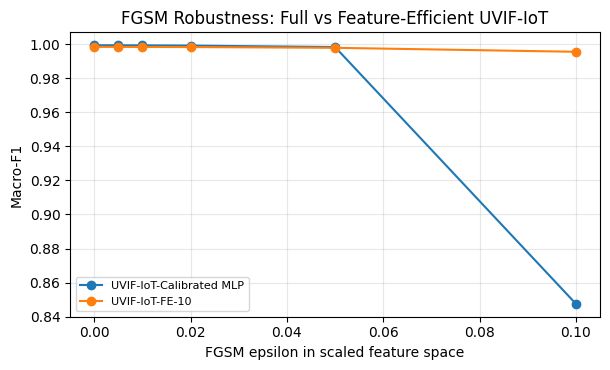

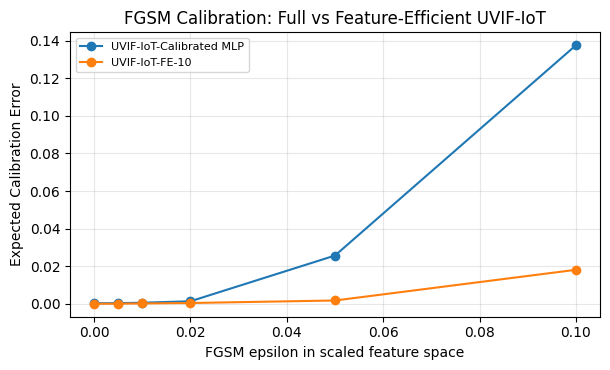

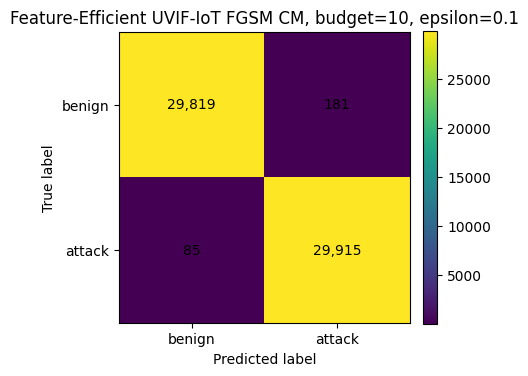


[Selected feature-efficient model]
Feature budget          : 10
Number of features      : 10 / 115
Feature reduction       : 91.30%
Temperature             : 1.078322

[Selected features]
01. HH_jit_L0.01_mean
02. H_L0.01_weight
03. MI_dir_L0.1_weight
04. HpHp_L0.1_weight
05. HpHp_L0.01_radius
06. HpHp_L0.01_weight
07. H_L0.1_weight
08. HpHp_L0.01_std
09. MI_dir_L0.01_weight
10. HH_jit_L0.1_mean

[FGSM results: feature-efficient model]
         model  epsilon  accuracy  macro_f1  balanced_accuracy      ece  macro_f1_drop_from_clean
UVIF-IoT-FE-10    0.000  0.998450  0.998450           0.998450 0.000092                  0.000000
UVIF-IoT-FE-10    0.005  0.998433  0.998433           0.998433 0.000162                  0.000017
UVIF-IoT-FE-10    0.010  0.998400  0.998400           0.998400 0.000269                  0.000050
UVIF-IoT-FE-10    0.020  0.998350  0.998350           0.998350 0.000508                  0.000100
UVIF-IoT-FE-10    0.050  0.997900  0.997900           0.997900 0.0018

In [13]:
# Cell 12 - Robustness of the selected feature-efficient UVIF-IoT model

print("=" * 80)
print("Cell 12 | Feature-Efficient UVIF-IoT Robustness")
print("=" * 80)

set_seed(SEED)

selected_budget = best_feature_budget
selected_obj = feature_budget_models[selected_budget]

selected_model = selected_obj["model"]
selected_temperature = float(selected_obj.get("temperature", temperature_value))
selected_idx = selected_obj["selected_idx"]
selected_features = selected_obj["selected_features"]

X_train_fe = X_train[:, selected_idx]
X_test_fe = X_test[:, selected_idx]

fe_min = X_train_fe.min(axis=0).astype(np.float32)
fe_max = X_train_fe.max(axis=0).astype(np.float32)

fe_min_tensor = torch.tensor(fe_min, dtype=torch.float32, device=DEVICE).view(1, -1)
fe_max_tensor = torch.tensor(fe_max, dtype=torch.float32, device=DEVICE).view(1, -1)


def fgsm_batch_with_bounds(model, xb, yb, epsilon, x_min, x_max):
    if epsilon == 0:
        return xb.detach()

    model.eval()

    x_adv = xb.detach().clone()
    x_adv.requires_grad_(True)

    logits = model(x_adv)
    loss = F.cross_entropy(logits, yb)

    grad = torch.autograd.grad(loss, x_adv)[0]

    x_adv = x_adv + epsilon * grad.sign()
    x_adv = torch.max(torch.min(x_adv, x_max), x_min)

    return x_adv.detach()


def evaluate_fgsm_with_bounds(
    model,
    X_np,
    y_np,
    epsilons,
    x_min,
    x_max,
    temperature=None,
    batch_size=512,
):
    model.eval()

    rows = []
    predictions = {}

    ds = TensorDataset(
        torch.tensor(X_np, dtype=torch.float32),
        torch.tensor(y_np, dtype=torch.long),
    )

    dl = DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=CONFIG["num_workers"],
        pin_memory=CUDA_AVAILABLE,
    )

    for eps in epsilons:
        all_logits = []
        all_y = []

        t0 = time.time()

        for xb, yb in dl:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)

            x_adv = fgsm_batch_with_bounds(
                model=model,
                xb=xb,
                yb=yb,
                epsilon=eps,
                x_min=x_min,
                x_max=x_max,
            )

            with torch.no_grad():
                logits = model(x_adv)

            all_logits.append(logits.detach().cpu())
            all_y.append(yb.detach().cpu())

        logits_np = torch.cat(all_logits, dim=0).numpy()
        y_true_np = torch.cat(all_y, dim=0).numpy()

        if temperature is not None:
            logits_np_for_proba = logits_np / float(temperature)
        else:
            logits_np_for_proba = logits_np

        proba_np = softmax_from_logits(logits_np_for_proba)
        pred_np = np.argmax(proba_np, axis=1)

        metrics = classification_metrics(y_true_np, pred_np)
        cal_row, bins_df = calibration_summary(
            model_name="tmp",
            split_name="fgsm_test",
            y_true=y_true_np,
            y_proba=proba_np,
            n_bins=CONFIG["calibration_bins"],
        )

        rows.append({
            "epsilon": float(eps),
            "n_samples": int(len(y_true_np)),
            "accuracy": metrics["accuracy"],
            "macro_f1": metrics["macro_f1"],
            "weighted_f1": metrics["weighted_f1"],
            "balanced_accuracy": metrics["balanced_accuracy"],
            "ece": cal_row["ece"],
            "brier_score": cal_row["brier_score"],
            "mean_confidence": cal_row["mean_confidence"],
            "eval_time_sec": round(time.time() - t0, 3),
        })

        predictions[float(eps)] = {
            "y_true": y_true_np,
            "y_pred": pred_np,
            "proba": proba_np,
            "logits": logits_np,
            "bins": bins_df,
        }

    return pd.DataFrame(rows), predictions


t0 = time.time()

fgsm_fe_df, fgsm_fe_preds = evaluate_fgsm_with_bounds(
    model=selected_model,
    X_np=X_test_fe,
    y_np=y_test,
    epsilons=FGSM_EPSILONS,
    x_min=fe_min_tensor,
    x_max=fe_max_tensor,
    temperature=selected_temperature,
    batch_size=CONFIG["batch_size"],
)

fgsm_fe_df.insert(0, "model", f"UVIF-IoT-FE-{selected_budget}")

clean_fe_f1 = float(fgsm_fe_df.loc[fgsm_fe_df["epsilon"] == 0.0, "macro_f1"].iloc[0])
clean_fe_acc = float(fgsm_fe_df.loc[fgsm_fe_df["epsilon"] == 0.0, "accuracy"].iloc[0])

fgsm_fe_df["macro_f1_drop_from_clean"] = clean_fe_f1 - fgsm_fe_df["macro_f1"]
fgsm_fe_df["accuracy_drop_from_clean"] = clean_fe_acc - fgsm_fe_df["accuracy"]

feature_fgsm_time = time.time() - t0

robustness_results.extend(fgsm_fe_df.to_dict(orient="records"))

fgsm_fe_path = TABLES_DIR / "uvif_feature_efficient_fgsm_results.csv"
fgsm_fe_df.to_csv(fgsm_fe_path, index=False)

robustness_running_path = TABLES_DIR / "robustness_results_running.csv"
pd.DataFrame(robustness_results).to_csv(robustness_running_path, index=False)

# Combine full calibrated MLP and selected feature-efficient model for plotting.
fgsm_compare_df = pd.concat(
    [
        fgsm_results_df[fgsm_results_df["model"] == "UVIF-IoT-Calibrated MLP"].copy(),
        fgsm_fe_df.copy(),
    ],
    axis=0,
    ignore_index=True,
)

fgsm_compare_path = TABLES_DIR / "uvif_full_vs_feature_efficient_fgsm.csv"
fgsm_compare_df.to_csv(fgsm_compare_path, index=False)

max_eps = max(FGSM_EPSILONS)
max_eps_fe = fgsm_fe_preds[float(max_eps)]

fgsm_fe_max_predictions_df = pd.DataFrame({
    "y_true": max_eps_fe["y_true"],
    "y_pred": max_eps_fe["y_pred"],
    "p_benign": max_eps_fe["proba"][:, 0],
    "p_attack": max_eps_fe["proba"][:, 1],
    "confidence": np.max(max_eps_fe["proba"], axis=1),
    "correct": max_eps_fe["y_true"] == max_eps_fe["y_pred"],
    "epsilon": float(max_eps),
    "feature_budget": selected_budget,
})

fgsm_fe_max_predictions_path = TABLES_DIR / "uvif_feature_efficient_fgsm_max_epsilon_predictions.csv"
fgsm_fe_max_predictions_df.to_csv(fgsm_fe_max_predictions_path, index=False)


# ---------------------------------------------------------------------
# Figures
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(6.2, 3.8))

for model_name, group in fgsm_compare_df.groupby("model"):
    group = group.sort_values("epsilon")
    ax.plot(group["epsilon"], group["macro_f1"], marker="o", label=model_name)

ax.set_title("FGSM Robustness: Full vs Feature-Efficient UVIF-IoT")
ax.set_xlabel("FGSM epsilon in scaled feature space")
ax.set_ylabel("Macro-F1")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

fig.tight_layout()
fe_fgsm_macro_png, fe_fgsm_macro_pdf = save_current_figure(
    "uvif_full_vs_feature_efficient_fgsm_macro_f1"
)
plt.show()


fig, ax = plt.subplots(figsize=(6.2, 3.8))

for model_name, group in fgsm_compare_df.groupby("model"):
    group = group.sort_values("epsilon")
    ax.plot(group["epsilon"], group["ece"], marker="o", label=model_name)

ax.set_title("FGSM Calibration: Full vs Feature-Efficient UVIF-IoT")
ax.set_xlabel("FGSM epsilon in scaled feature space")
ax.set_ylabel("Expected Calibration Error")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

fig.tight_layout()
fe_fgsm_ece_png, fe_fgsm_ece_pdf = save_current_figure(
    "uvif_full_vs_feature_efficient_fgsm_ece"
)
plt.show()


cm_fe_fgsm, cm_fe_fgsm_png, cm_fe_fgsm_pdf = plot_confusion_matrix(
    y_true=max_eps_fe["y_true"],
    y_pred=max_eps_fe["y_pred"],
    title=f"Feature-Efficient UVIF-IoT FGSM CM, budget={selected_budget}, epsilon={max_eps}",
    file_stem="uvif_feature_efficient_fgsm_max_epsilon_confusion_matrix",
)


# ---------------------------------------------------------------------
# Console report
# ---------------------------------------------------------------------

print("\n[Selected feature-efficient model]")
print(f"Feature budget          : {selected_budget}")
print(f"Number of features      : {len(selected_features)} / {len(feature_names)}")
print(f"Feature reduction       : {100 * (1 - len(selected_features) / len(feature_names)):.2f}%")
print(f"Temperature             : {selected_temperature:.6f}")

print("\n[Selected features]")
for i, feat in enumerate(selected_features, start=1):
    print(f"{i:02d}. {feat}")

print("\n[FGSM results: feature-efficient model]")
display_cols = [
    "model",
    "epsilon",
    "accuracy",
    "macro_f1",
    "balanced_accuracy",
    "ece",
    "macro_f1_drop_from_clean",
]
print(fgsm_fe_df[display_cols].to_string(index=False))

print("\n[FGSM comparison: full calibrated vs feature-efficient]")
print(
    fgsm_compare_df[
        ["model", "epsilon", "macro_f1", "ece", "macro_f1_drop_from_clean"]
    ].to_string(index=False)
)

print(f"\n[Strongest epsilon confusion matrix: epsilon={max_eps}]")
print(pd.DataFrame(
    cm_fe_fgsm,
    index=["true_benign", "true_attack"],
    columns=["pred_benign", "pred_attack"],
).to_string())

print("\n[Runtime]")
print(f"Feature-efficient FGSM evaluation time: {feature_fgsm_time:.3f} sec")

print("\n[Saved]")
print(f"Feature-efficient FGSM table      : {fgsm_fe_path}")
print(f"Full-vs-FE FGSM comparison table  : {fgsm_compare_path}")
print(f"Robustness running table          : {robustness_running_path}")
print(f"Max-epsilon FE predictions        : {fgsm_fe_max_predictions_path}")
print(f"Macro-F1 comparison PNG/PDF       : {fe_fgsm_macro_png}")
print(f"ECE comparison PNG/PDF            : {fe_fgsm_ece_png}")
print(f"Max-epsilon FE confusion PNG/PDF  : {cm_fe_fgsm_png}")

print("\nCell 12 complete.")
print("=" * 80)

Cell 13 | Corrected PGD Robustness Evaluation


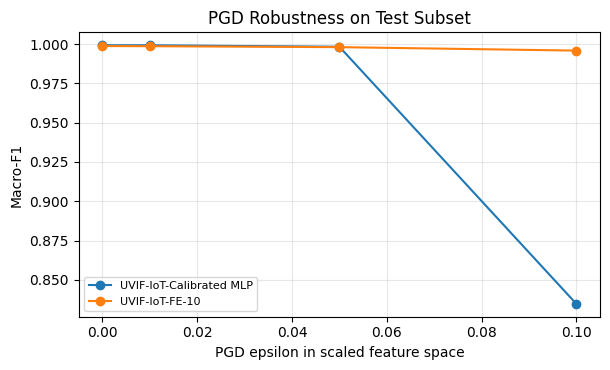

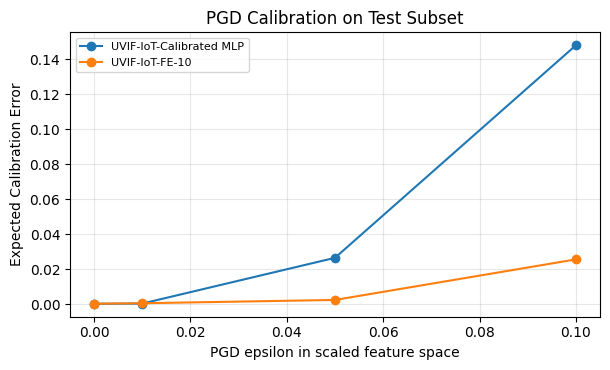

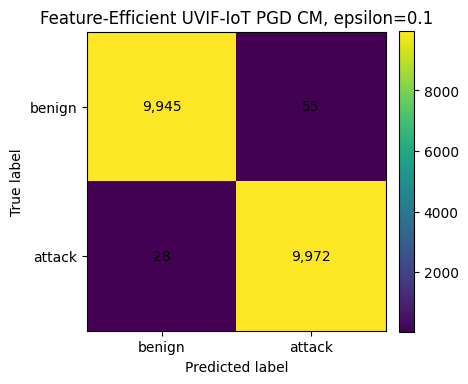


[PGD setup]
Evaluation subset samples : 20,000 / 60,000
Class counts in subset    : {0: np.int64(10000), 1: np.int64(10000)}
Evaluated epsilons        : [0.0, 0.01, 0.05, 0.1]
PGD steps                 : 10
PGD alpha schedule        : alpha = 2.5 * epsilon / steps
Attack start              : deterministic random start inside epsilon ball
Attack space              : each model's active scaled feature space
Total PGD eval time       : 5.168 sec

[PGD robustness results]
                  model  epsilon  pgd_alpha  accuracy  macro_f1  balanced_accuracy      ece  macro_f1_drop_from_clean
UVIF-IoT-Calibrated MLP     0.00     0.0000   0.99925  0.999250            0.99925 0.000380                  0.000000
UVIF-IoT-Calibrated MLP     0.01     0.0025   0.99925  0.999250            0.99925 0.000514                  0.000000
UVIF-IoT-Calibrated MLP     0.05     0.0125   0.99830  0.998300            0.99830 0.026637                  0.000950
UVIF-IoT-Calibrated MLP     0.10     0.0250   0.83740 

In [15]:
# Cell 13 - Corrected PGD robustness evaluation on a reproducible test subset

print("=" * 80)
print("Cell 13 | Corrected PGD Robustness Evaluation")
print("=" * 80)

set_seed(SEED)

PGD_EPSILONS = [0.0, 0.01, 0.05, 0.10]
PGD_STEPS = 10
PGD_MAX_SAMPLES = 20_000

# For a stronger projected attack, the step size is tied to epsilon.
# For eps > 0, alpha = 2.5 * eps / steps.
# This allows the attack to reach the epsilon ball while still using projection.
def pgd_alpha_for_epsilon(eps, steps):
    if eps == 0:
        return 0.0
    return 2.5 * float(eps) / int(steps)


# Stratified subset for pilot PGD evaluation.
pgd_idx_all = np.arange(len(y_test))

if len(y_test) > PGD_MAX_SAMPLES:
    _, pgd_idx = train_test_split(
        pgd_idx_all,
        test_size=PGD_MAX_SAMPLES,
        random_state=SEED,
        stratify=y_test,
    )
    pgd_idx = np.sort(pgd_idx)
else:
    pgd_idx = pgd_idx_all

X_test_pgd = X_test[pgd_idx]
y_test_pgd = y_test[pgd_idx]

X_test_fe_pgd = X_test_fe[pgd_idx]


def pgd_batch(model, xb, yb, epsilon, alpha, steps, x_min, x_max):
    if epsilon == 0:
        return xb.detach()

    model.eval()

    x_orig = xb.detach()

    # Deterministic random start inside the epsilon ball.
    # The notebook seed is fixed, so this remains reproducible.
    x_adv = x_orig + torch.empty_like(x_orig).uniform_(-epsilon, epsilon)
    x_adv = torch.max(torch.min(x_adv, x_max), x_min)

    for _ in range(steps):
        x_adv.requires_grad_(True)

        logits = model(x_adv)
        loss = F.cross_entropy(logits, yb)

        grad = torch.autograd.grad(loss, x_adv)[0]

        x_adv = x_adv.detach() + alpha * grad.sign()

        # Project to L-infinity epsilon ball around the clean input.
        x_adv = torch.max(torch.min(x_adv, x_orig + epsilon), x_orig - epsilon)

        # Keep values inside the observed training bounds.
        x_adv = torch.max(torch.min(x_adv, x_max), x_min)

    return x_adv.detach()


def evaluate_pgd_with_bounds(
    model,
    X_np,
    y_np,
    epsilons,
    x_min,
    x_max,
    temperature=None,
    steps=10,
    batch_size=512,
):
    model.eval()

    rows = []
    predictions = {}

    ds = TensorDataset(
        torch.tensor(X_np, dtype=torch.float32),
        torch.tensor(y_np, dtype=torch.long),
    )

    dl = DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=CONFIG["num_workers"],
        pin_memory=CUDA_AVAILABLE,
    )

    for eps in epsilons:
        alpha = pgd_alpha_for_epsilon(eps, steps)

        all_logits = []
        all_y = []

        t0 = time.time()

        for xb, yb in dl:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)

            x_adv = pgd_batch(
                model=model,
                xb=xb,
                yb=yb,
                epsilon=float(eps),
                alpha=float(alpha),
                steps=int(steps),
                x_min=x_min,
                x_max=x_max,
            )

            with torch.no_grad():
                logits = model(x_adv)

            all_logits.append(logits.detach().cpu())
            all_y.append(yb.detach().cpu())

        logits_np = torch.cat(all_logits, dim=0).numpy()
        y_true_np = torch.cat(all_y, dim=0).numpy()

        if temperature is not None:
            logits_for_proba = logits_np / float(temperature)
        else:
            logits_for_proba = logits_np

        proba_np = softmax_from_logits(logits_for_proba)
        pred_np = np.argmax(proba_np, axis=1)

        metrics = classification_metrics(y_true_np, pred_np)

        cal_row, bins_df = calibration_summary(
            model_name="tmp",
            split_name="pgd_test_subset",
            y_true=y_true_np,
            y_proba=proba_np,
            n_bins=CONFIG["calibration_bins"],
        )

        rows.append({
            "attack": "PGD",
            "model": None,
            "epsilon": float(eps),
            "pgd_alpha": float(alpha),
            "pgd_steps": int(steps),
            "n_samples": int(len(y_true_np)),
            "accuracy": metrics["accuracy"],
            "macro_f1": metrics["macro_f1"],
            "weighted_f1": metrics["weighted_f1"],
            "balanced_accuracy": metrics["balanced_accuracy"],
            "ece": cal_row["ece"],
            "brier_score": cal_row["brier_score"],
            "mean_confidence": cal_row["mean_confidence"],
            "eval_time_sec": round(time.time() - t0, 3),
        })

        predictions[float(eps)] = {
            "y_true": y_true_np,
            "y_pred": pred_np,
            "proba": proba_np,
            "logits": logits_np,
            "bins": bins_df,
        }

    return pd.DataFrame(rows), predictions


t0 = time.time()

pgd_full_df, pgd_full_preds = evaluate_pgd_with_bounds(
    model=mlp,
    X_np=X_test_pgd,
    y_np=y_test_pgd,
    epsilons=PGD_EPSILONS,
    x_min=x_min_tensor,
    x_max=x_max_tensor,
    temperature=temperature_value,
    steps=PGD_STEPS,
    batch_size=CONFIG["batch_size"],
)

pgd_full_df["model"] = "UVIF-IoT-Calibrated MLP"

pgd_fe_df, pgd_fe_preds = evaluate_pgd_with_bounds(
    model=selected_model,
    X_np=X_test_fe_pgd,
    y_np=y_test_pgd,
    epsilons=PGD_EPSILONS,
    x_min=fe_min_tensor,
    x_max=fe_max_tensor,
    temperature=selected_temperature,
    steps=PGD_STEPS,
    batch_size=CONFIG["batch_size"],
)

pgd_fe_df["model"] = f"UVIF-IoT-FE-{selected_budget}"

pgd_time = time.time() - t0

pgd_results_df = pd.concat([pgd_full_df, pgd_fe_df], axis=0, ignore_index=True)

rows = []
for model_name, group in pgd_results_df.groupby("model"):
    clean_f1 = float(group.loc[group["epsilon"] == 0.0, "macro_f1"].iloc[0])
    clean_acc = float(group.loc[group["epsilon"] == 0.0, "accuracy"].iloc[0])

    for _, row in group.iterrows():
        item = row.to_dict()
        item["macro_f1_drop_from_clean"] = clean_f1 - float(row["macro_f1"])
        item["accuracy_drop_from_clean"] = clean_acc - float(row["accuracy"])
        rows.append(item)

pgd_results_df = pd.DataFrame(rows)

# Remove earlier PGD rows from the running table, if Cell 13 was already run.
robustness_results = [
    r for r in robustness_results
    if not (
        str(r.get("model", "")).startswith("UVIF-IoT")
        and "pgd_steps" in r
    )
]

robustness_results.extend(pgd_results_df.to_dict(orient="records"))

pgd_results_path = TABLES_DIR / "pgd_robustness_results_subset.csv"
pgd_results_df.to_csv(pgd_results_path, index=False)

robustness_running_path = TABLES_DIR / "robustness_results_running.csv"
pd.DataFrame(robustness_results).to_csv(robustness_running_path, index=False)


# ---------------------------------------------------------------------
# Save strongest-epsilon predictions
# ---------------------------------------------------------------------

max_pgd_eps = max(PGD_EPSILONS)

pgd_full_max = pgd_full_preds[float(max_pgd_eps)]
pgd_fe_max = pgd_fe_preds[float(max_pgd_eps)]

pgd_full_max_path = TABLES_DIR / "uvif_full_pgd_max_epsilon_predictions_subset.csv"
pd.DataFrame({
    "y_true": pgd_full_max["y_true"],
    "y_pred": pgd_full_max["y_pred"],
    "p_benign": pgd_full_max["proba"][:, 0],
    "p_attack": pgd_full_max["proba"][:, 1],
    "confidence": np.max(pgd_full_max["proba"], axis=1),
    "correct": pgd_full_max["y_true"] == pgd_full_max["y_pred"],
    "epsilon": float(max_pgd_eps),
}).to_csv(pgd_full_max_path, index=False)

pgd_fe_max_path = TABLES_DIR / "uvif_fe_pgd_max_epsilon_predictions_subset.csv"
pd.DataFrame({
    "y_true": pgd_fe_max["y_true"],
    "y_pred": pgd_fe_max["y_pred"],
    "p_benign": pgd_fe_max["proba"][:, 0],
    "p_attack": pgd_fe_max["proba"][:, 1],
    "confidence": np.max(pgd_fe_max["proba"], axis=1),
    "correct": pgd_fe_max["y_true"] == pgd_fe_max["y_pred"],
    "epsilon": float(max_pgd_eps),
    "feature_budget": selected_budget,
}).to_csv(pgd_fe_max_path, index=False)


# ---------------------------------------------------------------------
# Figures
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(6.2, 3.8))

for model_name, group in pgd_results_df.groupby("model"):
    group = group.sort_values("epsilon")
    ax.plot(group["epsilon"], group["macro_f1"], marker="o", label=model_name)

ax.set_title("PGD Robustness on Test Subset")
ax.set_xlabel("PGD epsilon in scaled feature space")
ax.set_ylabel("Macro-F1")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

fig.tight_layout()
pgd_macro_png, pgd_macro_pdf = save_current_figure("pgd_macro_f1_subset")
plt.show()


fig, ax = plt.subplots(figsize=(6.2, 3.8))

for model_name, group in pgd_results_df.groupby("model"):
    group = group.sort_values("epsilon")
    ax.plot(group["epsilon"], group["ece"], marker="o", label=model_name)

ax.set_title("PGD Calibration on Test Subset")
ax.set_xlabel("PGD epsilon in scaled feature space")
ax.set_ylabel("Expected Calibration Error")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

fig.tight_layout()
pgd_ece_png, pgd_ece_pdf = save_current_figure("pgd_ece_subset")
plt.show()


cm_pgd_fe, cm_pgd_fe_png, cm_pgd_fe_pdf = plot_confusion_matrix(
    y_true=pgd_fe_max["y_true"],
    y_pred=pgd_fe_max["y_pred"],
    title=f"Feature-Efficient UVIF-IoT PGD CM, epsilon={max_pgd_eps}",
    file_stem="uvif_fe_pgd_max_epsilon_confusion_matrix_subset",
)


# ---------------------------------------------------------------------
# Console report
# ---------------------------------------------------------------------

print("\n[PGD setup]")
print(f"Evaluation subset samples : {len(y_test_pgd):,} / {len(y_test):,}")
print(f"Class counts in subset    : {dict(pd.Series(y_test_pgd).value_counts().sort_index())}")
print(f"Evaluated epsilons        : {PGD_EPSILONS}")
print(f"PGD steps                 : {PGD_STEPS}")
print("PGD alpha schedule        : alpha = 2.5 * epsilon / steps")
print(f"Attack start              : deterministic random start inside epsilon ball")
print(f"Attack space              : each model's active scaled feature space")
print(f"Total PGD eval time       : {pgd_time:.3f} sec")

print("\n[PGD robustness results]")
display_cols = [
    "model",
    "epsilon",
    "pgd_alpha",
    "accuracy",
    "macro_f1",
    "balanced_accuracy",
    "ece",
    "macro_f1_drop_from_clean",
]
print(pgd_results_df[display_cols].to_string(index=False))

print(f"\n[Feature-efficient strongest-epsilon confusion matrix: epsilon={max_pgd_eps}]")
print(pd.DataFrame(
    cm_pgd_fe,
    index=["true_benign", "true_attack"],
    columns=["pred_benign", "pred_attack"],
).to_string())

print("\n[Saved]")
print(f"PGD robustness table             : {pgd_results_path}")
print(f"Robustness running table         : {robustness_running_path}")
print(f"Full model max-eps predictions   : {pgd_full_max_path}")
print(f"FE model max-eps predictions     : {pgd_fe_max_path}")
print(f"PGD Macro-F1 plot PNG/PDF        : {pgd_macro_png}")
print(f"PGD ECE plot PNG/PDF             : {pgd_ece_png}")
print(f"FE PGD confusion PNG/PDF         : {cm_pgd_fe_png}")

print("\nCell 13 complete.")
print("=" * 80)

Cell 14 | Consolidated Results and Ablation Tables


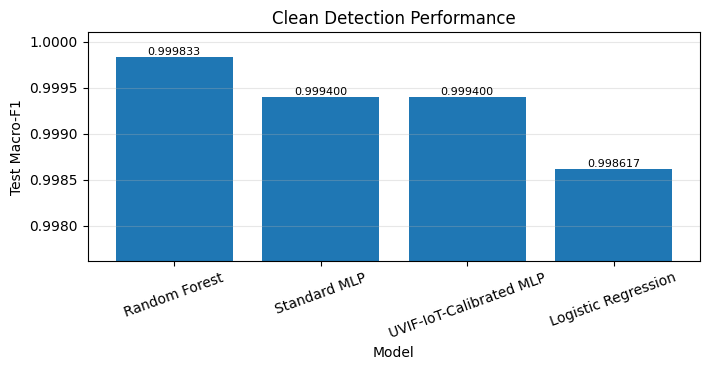

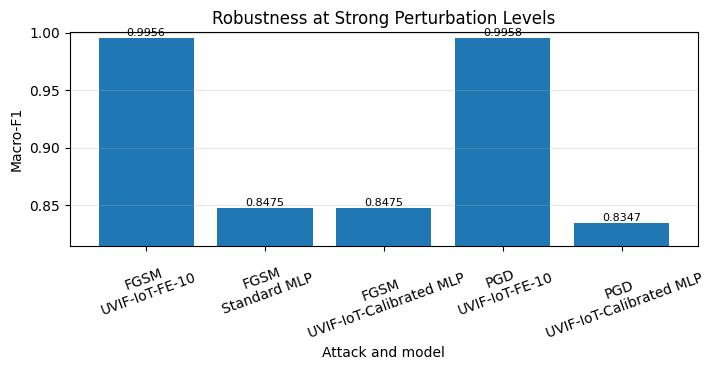

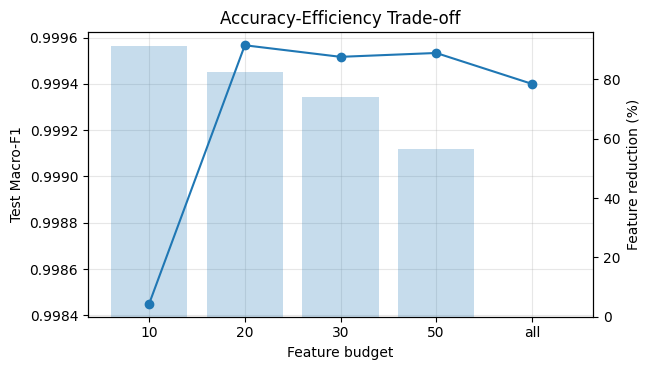


[Clean performance: test split]
                  model  n_features  accuracy  macro_f1  weighted_f1  balanced_accuracy
          Random Forest         115  0.999833  0.999833     0.999833           0.999833
           Standard MLP         115  0.999400  0.999400     0.999400           0.999400
UVIF-IoT-Calibrated MLP         115  0.999400  0.999400     0.999400           0.999400
    Logistic Regression         115  0.998617  0.998617     0.998617           0.998617

[Calibration summary: test split]
                  model      ece  brier_score  mean_confidence
          Random Forest 0.000170     0.000106         0.999752
    Logistic Regression 0.000321     0.001239         0.998937
UVIF-IoT-Calibrated MLP 0.000351     0.000558         0.999134
           Standard MLP 0.000524     0.000547         0.999677

[Robustness summary at strongest reported epsilon]
attack                   model  epsilon  n_samples  accuracy  macro_f1  balanced_accuracy      ece  macro_f1_drop_from_clean


In [16]:
# Cell 14 - Consolidated results and ablation tables

print("=" * 80)
print("Cell 14 | Consolidated Results and Ablation Tables")
print("=" * 80)

# ---------------------------------------------------------------------
# Clean performance table
# ---------------------------------------------------------------------

clean_df = pd.DataFrame(clean_results).copy()
clean_test_df = clean_df[clean_df["split"] == "test"].copy()

clean_test_df = clean_test_df[
    [
        "model",
        "n_features",
        "accuracy",
        "macro_f1",
        "weighted_f1",
        "balanced_accuracy",
        "train_time_sec",
        "notes",
    ]
].sort_values("macro_f1", ascending=False).reset_index(drop=True)

clean_paper_path = TABLES_DIR / "paper_clean_performance.csv"
clean_test_df.to_csv(clean_paper_path, index=False)


# ---------------------------------------------------------------------
# Calibration table
# ---------------------------------------------------------------------

cal_df = pd.DataFrame(calibration_results).copy()
cal_test_df = cal_df[cal_df["split"] == "test"].copy()

cal_test_df = cal_test_df[
    [
        "model",
        "ece",
        "brier_score",
        "mean_confidence",
        "median_confidence",
        "accuracy",
        "n_bins",
    ]
].sort_values("ece", ascending=True).reset_index(drop=True)

cal_paper_path = TABLES_DIR / "paper_calibration_summary.csv"
cal_test_df.to_csv(cal_paper_path, index=False)


# ---------------------------------------------------------------------
# Robustness summary at strongest perturbation
# ---------------------------------------------------------------------

FGSM_REPORT_EPS = max(FGSM_EPSILONS)
PGD_REPORT_EPS = max(PGD_EPSILONS)

fgsm_key_df = pd.concat(
    [
        fgsm_results_df.copy(),
        fgsm_fe_df.copy(),
    ],
    axis=0,
    ignore_index=True,
)

fgsm_key_df = fgsm_key_df[fgsm_key_df["epsilon"] == FGSM_REPORT_EPS].copy()
fgsm_key_df["attack"] = "FGSM"

pgd_key_df = pgd_results_df[pgd_results_df["epsilon"] == PGD_REPORT_EPS].copy()
pgd_key_df["attack"] = "PGD"

robust_key_df = pd.concat([fgsm_key_df, pgd_key_df], axis=0, ignore_index=True)

robust_key_df = robust_key_df[
    [
        "attack",
        "model",
        "epsilon",
        "n_samples",
        "accuracy",
        "macro_f1",
        "balanced_accuracy",
        "ece",
        "macro_f1_drop_from_clean",
    ]
].sort_values(["attack", "macro_f1"], ascending=[True, False]).reset_index(drop=True)

robust_paper_path = TABLES_DIR / "paper_robustness_summary.csv"
robust_key_df.to_csv(robust_paper_path, index=False)


# ---------------------------------------------------------------------
# Feature-efficiency paper table
# ---------------------------------------------------------------------

feature_paper_df = feature_efficiency_df[
    [
        "feature_budget",
        "n_features",
        "feature_reduction_pct",
        "trainable_parameters",
        "test_accuracy",
        "test_macro_f1",
        "test_balanced_accuracy",
        "test_ece",
        "temperature",
        "train_time_sec",
    ]
].copy()

feature_paper_path = TABLES_DIR / "paper_feature_efficiency_summary.csv"
feature_paper_df.to_csv(feature_paper_path, index=False)


# ---------------------------------------------------------------------
# Main ablation table
# ---------------------------------------------------------------------

def get_clean_row(model_name):
    row = clean_test_df[clean_test_df["model"] == model_name]
    if row.empty:
        return None
    return row.iloc[0].to_dict()


def get_cal_row(model_name):
    row = cal_test_df[cal_test_df["model"] == model_name]
    if row.empty:
        return None
    return row.iloc[0].to_dict()


def get_fgsm_value(model_name, eps=FGSM_REPORT_EPS):
    rows = pd.concat([fgsm_results_df, fgsm_fe_df], axis=0, ignore_index=True)
    row = rows[(rows["model"] == model_name) & (rows["epsilon"] == eps)]
    if row.empty:
        return None
    return row.iloc[0].to_dict()


def get_pgd_value(model_name, eps=PGD_REPORT_EPS):
    row = pgd_results_df[(pgd_results_df["model"] == model_name) & (pgd_results_df["epsilon"] == eps)]
    if row.empty:
        return None
    return row.iloc[0].to_dict()


ablation_specs = [
    {
        "variant": "Classical linear baseline",
        "model": "Logistic Regression",
        "components": "scaled features",
    },
    {
        "variant": "Classical tree baseline",
        "model": "Random Forest",
        "components": "raw features + RF ranking",
    },
    {
        "variant": "Neural baseline",
        "model": "Standard MLP",
        "components": "MLP",
    },
    {
        "variant": "Uncertainty/calibration",
        "model": "UVIF-IoT-Calibrated MLP",
        "components": "MLP + temperature scaling + entropy/confidence uncertainty",
    },
    {
        "variant": "Full UVIF-IoT compact",
        "model": f"UVIF-IoT-FE-{best_feature_budget}",
        "components": "RF-ranked feature budget + calibrated MLP + robustness evaluation",
    },
]

ablation_rows = []

for spec in ablation_specs:
    model_name = spec["model"]

    clean_row = get_clean_row(model_name)
    cal_row = get_cal_row(model_name)

    if clean_row is None and model_name.startswith("UVIF-IoT-FE"):
        fe_row = feature_efficiency_df[
            feature_efficiency_df["feature_budget"] == best_feature_budget
        ].iloc[0]

        clean_row = {
            "n_features": int(fe_row["n_features"]),
            "accuracy": float(fe_row["test_accuracy"]),
            "macro_f1": float(fe_row["test_macro_f1"]),
            "weighted_f1": float(fe_row["test_weighted_f1"]),
            "balanced_accuracy": float(fe_row["test_balanced_accuracy"]),
            "train_time_sec": float(fe_row["train_time_sec"]),
        }

        cal_row = {
            "ece": float(fe_row["test_ece"]),
            "brier_score": float(fe_row["test_brier_score"]),
            "mean_confidence": np.nan,
        }

    fgsm_row = get_fgsm_value(model_name)
    pgd_row = get_pgd_value(model_name)

    ablation_rows.append({
        "variant": spec["variant"],
        "model": model_name,
        "components": spec["components"],
        "n_features": clean_row["n_features"] if clean_row is not None else np.nan,
        "feature_reduction_pct": (
            100.0 * (1.0 - clean_row["n_features"] / len(feature_names))
            if clean_row is not None and pd.notna(clean_row["n_features"])
            else np.nan
        ),
        "clean_accuracy": clean_row["accuracy"] if clean_row is not None else np.nan,
        "clean_macro_f1": clean_row["macro_f1"] if clean_row is not None else np.nan,
        "clean_balanced_accuracy": clean_row["balanced_accuracy"] if clean_row is not None else np.nan,
        "ece": cal_row["ece"] if cal_row is not None else np.nan,
        "brier_score": cal_row["brier_score"] if cal_row is not None else np.nan,
        "fgsm_eps": FGSM_REPORT_EPS if fgsm_row is not None else np.nan,
        "fgsm_macro_f1": fgsm_row["macro_f1"] if fgsm_row is not None else np.nan,
        "fgsm_macro_f1_drop": fgsm_row["macro_f1_drop_from_clean"] if fgsm_row is not None else np.nan,
        "pgd_eps": PGD_REPORT_EPS if pgd_row is not None else np.nan,
        "pgd_macro_f1": pgd_row["macro_f1"] if pgd_row is not None else np.nan,
        "pgd_macro_f1_drop": pgd_row["macro_f1_drop_from_clean"] if pgd_row is not None else np.nan,
        "train_time_sec": clean_row.get("train_time_sec", np.nan) if clean_row is not None else np.nan,
    })

ablation_df = pd.DataFrame(ablation_rows)

ablation_path = TABLES_DIR / "paper_ablation_summary.csv"
ablation_df.to_csv(ablation_path, index=False)


# ---------------------------------------------------------------------
# LaTeX-ready table snippets
# ---------------------------------------------------------------------

def save_latex_table(df, path, float_format="%.6f"):
    latex = df.to_latex(
        index=False,
        float_format=float_format,
        escape=True,
    )

    with open(path, "w", encoding="utf-8") as f:
        f.write(latex)

    return path


clean_latex_path = TABLES_DIR / "paper_clean_performance.tex"
cal_latex_path = TABLES_DIR / "paper_calibration_summary.tex"
robust_latex_path = TABLES_DIR / "paper_robustness_summary.tex"
feature_latex_path = TABLES_DIR / "paper_feature_efficiency_summary.tex"
ablation_latex_path = TABLES_DIR / "paper_ablation_summary.tex"

save_latex_table(
    clean_test_df[
        ["model", "n_features", "accuracy", "macro_f1", "weighted_f1", "balanced_accuracy"]
    ],
    clean_latex_path,
)

save_latex_table(
    cal_test_df[
        ["model", "ece", "brier_score", "mean_confidence"]
    ],
    cal_latex_path,
)

save_latex_table(
    robust_key_df[
        ["attack", "model", "epsilon", "macro_f1", "balanced_accuracy", "ece", "macro_f1_drop_from_clean"]
    ],
    robust_latex_path,
)

save_latex_table(
    feature_paper_df[
        ["feature_budget", "n_features", "feature_reduction_pct", "test_macro_f1", "test_ece"]
    ],
    feature_latex_path,
)

save_latex_table(
    ablation_df[
        [
            "variant",
            "model",
            "n_features",
            "feature_reduction_pct",
            "clean_macro_f1",
            "ece",
            "fgsm_macro_f1",
            "pgd_macro_f1",
        ]
    ],
    ablation_latex_path,
)


# ---------------------------------------------------------------------
# Paper-ready figures
# ---------------------------------------------------------------------

clean_plot_df = clean_test_df.copy()

fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.bar(clean_plot_df["model"], clean_plot_df["macro_f1"])
ax.set_title("Clean Detection Performance")
ax.set_xlabel("Model")
ax.set_ylabel("Test Macro-F1")
ax.set_ylim(max(0.995, clean_plot_df["macro_f1"].min() - 0.001), 1.0001)
ax.grid(axis="y", alpha=0.3)
ax.tick_params(axis="x", rotation=20)

for i, v in enumerate(clean_plot_df["macro_f1"]):
    ax.text(i, v, f"{v:.6f}", ha="center", va="bottom", fontsize=8)

fig.tight_layout()
clean_bar_png, clean_bar_pdf = save_current_figure("paper_clean_macro_f1_comparison")
plt.show()


robust_plot_df = robust_key_df.copy()
robust_plot_df["label"] = robust_plot_df["attack"] + "\n" + robust_plot_df["model"]

fig, ax = plt.subplots(figsize=(7.4, 3.8))
ax.bar(robust_plot_df["label"], robust_plot_df["macro_f1"])
ax.set_title(f"Robustness at Strong Perturbation Levels")
ax.set_xlabel("Attack and model")
ax.set_ylabel("Macro-F1")
ax.set_ylim(max(0.80, robust_plot_df["macro_f1"].min() - 0.02), 1.0005)
ax.grid(axis="y", alpha=0.3)
ax.tick_params(axis="x", rotation=20)

for i, v in enumerate(robust_plot_df["macro_f1"]):
    ax.text(i, v, f"{v:.4f}", ha="center", va="bottom", fontsize=8)

fig.tight_layout()
robust_bar_png, robust_bar_pdf = save_current_figure("paper_strong_attack_macro_f1_comparison")
plt.show()


fig, ax1 = plt.subplots(figsize=(6.6, 3.8))

x_labels = feature_paper_df["feature_budget"].astype(str)
x_pos = np.arange(len(x_labels))

ax1.plot(x_pos, feature_paper_df["test_macro_f1"], marker="o", label="Macro-F1")
ax1.set_xlabel("Feature budget")
ax1.set_ylabel("Test Macro-F1")
ax1.set_xticks(x_pos)
ax1.set_xticklabels(x_labels)
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
ax2.bar(x_pos, feature_paper_df["feature_reduction_pct"], alpha=0.25, label="Feature reduction")
ax2.set_ylabel("Feature reduction (%)")

ax1.set_title("Accuracy-Efficiency Trade-off")
fig.tight_layout()

tradeoff_png, tradeoff_pdf = save_current_figure("paper_accuracy_efficiency_tradeoff")
plt.show()


# ---------------------------------------------------------------------
# Reproducibility manifest
# ---------------------------------------------------------------------

manifest = {
    "experiment_name": EXPERIMENT_NAME,
    "seed": SEED,
    "dataset": {
        "name": "N-BaIoT",
        "pilot_samples": int(len(y)),
        "n_features": int(len(feature_names)),
        "train_samples": int(len(y_train)),
        "validation_samples": int(len(y_val)),
        "test_samples": int(len(y_test)),
        "sampling_mode": "pilot balanced sample",
    },
    "best_feature_budget": str(best_feature_budget),
    "best_feature_count": int(len(selected_features)),
    "best_feature_reduction_pct": float(100.0 * (1.0 - len(selected_features) / len(feature_names))),
    "main_tables": {
        "clean_performance": str(clean_paper_path),
        "calibration_summary": str(cal_paper_path),
        "robustness_summary": str(robust_paper_path),
        "feature_efficiency": str(feature_paper_path),
        "ablation_summary": str(ablation_path),
    },
    "main_figures": {
        "clean_macro_f1": str(clean_bar_png),
        "strong_attack_macro_f1": str(robust_bar_png),
        "accuracy_efficiency_tradeoff": str(tradeoff_png),
    },
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
}

manifest_path = LOGS_DIR / "paper_results_manifest.json"
with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=4)


# ---------------------------------------------------------------------
# Console report
# ---------------------------------------------------------------------

print("\n[Clean performance: test split]")
print(clean_test_df[
    ["model", "n_features", "accuracy", "macro_f1", "weighted_f1", "balanced_accuracy"]
].to_string(index=False))

print("\n[Calibration summary: test split]")
print(cal_test_df[
    ["model", "ece", "brier_score", "mean_confidence"]
].to_string(index=False))

print("\n[Robustness summary at strongest reported epsilon]")
print(robust_key_df.to_string(index=False))

print("\n[Feature-efficiency summary]")
print(feature_paper_df[
    ["feature_budget", "n_features", "feature_reduction_pct", "test_macro_f1", "test_ece"]
].to_string(index=False))

print("\n[Ablation summary]")
print(ablation_df[
    [
        "variant",
        "model",
        "n_features",
        "feature_reduction_pct",
        "clean_macro_f1",
        "ece",
        "fgsm_macro_f1",
        "pgd_macro_f1",
    ]
].to_string(index=False))

print("\n[Saved CSV tables]")
print(f"Clean performance      : {clean_paper_path}")
print(f"Calibration summary    : {cal_paper_path}")
print(f"Robustness summary     : {robust_paper_path}")
print(f"Feature efficiency     : {feature_paper_path}")
print(f"Ablation summary       : {ablation_path}")

print("\n[Saved LaTeX tables]")
print(f"Clean performance      : {clean_latex_path}")
print(f"Calibration summary    : {cal_latex_path}")
print(f"Robustness summary     : {robust_latex_path}")
print(f"Feature efficiency     : {feature_latex_path}")
print(f"Ablation summary       : {ablation_latex_path}")

print("\n[Saved figures]")
print(f"Clean Macro-F1 plot    : {clean_bar_png}")
print(f"Robustness plot        : {robust_bar_png}")
print(f"Trade-off plot         : {tradeoff_png}")

print("\n[Saved manifest]")
print(f"Results manifest       : {manifest_path}")

print("\nCell 14 complete.")
print("=" * 80)

Cell 15 | Deployment Footprint and Inference Timing


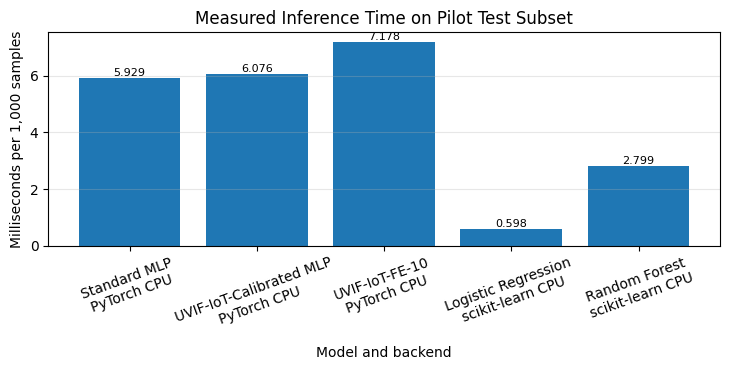

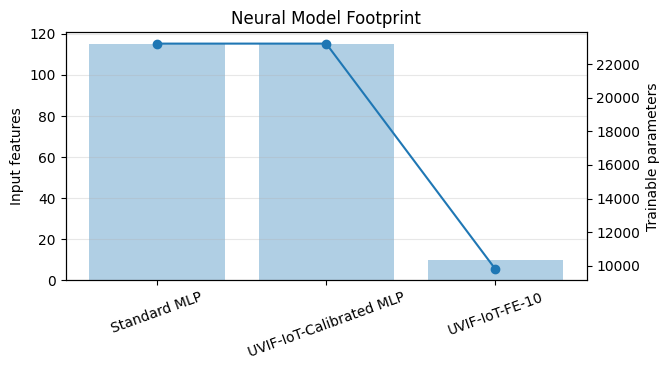


[Timing setup]
Timing samples           : 20,000
Repeats                  : 5
Batch size               : 1024
Selected device          : cuda
Reported timing          : wall-clock inference time only

[Deployment footprint and timing]
                  model  runtime_backend  n_samples  n_features  feature_reduction_pct  trainable_parameters  saved_model_size_mb  mean_time_sec  std_time_sec  samples_per_sec  ms_per_1000_samples
           Standard MLP      PyTorch CPU      20000         115               0.000000               23234.0             0.092790       0.118582      0.014804     1.686591e+05             5.929119
UVIF-IoT-Calibrated MLP      PyTorch CPU      20000         115               0.000000               23234.0             0.092790       0.121529      0.014553     1.645703e+05             6.076431
         UVIF-IoT-FE-10      PyTorch CPU      20000          10              91.304348                9794.0             0.041848       0.143561      0.073257     1.393137e+

In [17]:
# Cell 15 - Deployment footprint and inference timing

print("=" * 80)
print("Cell 15 | Deployment Footprint and Inference Timing")
print("=" * 80)

import copy

set_seed(SEED)

TIMING_SAMPLES = 20_000
TIMING_REPEATS = 5
TIMING_BATCH_SIZE = 1024

timing_idx_all = np.arange(len(y_test))

if len(y_test) > TIMING_SAMPLES:
    _, timing_idx = train_test_split(
        timing_idx_all,
        test_size=TIMING_SAMPLES,
        random_state=SEED,
        stratify=y_test,
    )
    timing_idx = np.sort(timing_idx)
else:
    timing_idx = timing_idx_all

X_timing_scaled = X_test[timing_idx]
X_timing_raw = X_test_raw.iloc[timing_idx].copy()
X_timing_fe = X_test_fe[timing_idx]
y_timing = y_test[timing_idx]


def file_size_mb(path):
    path = Path(path)
    if not path.exists():
        return np.nan
    return path.stat().st_size / (1024 ** 2)


def time_sklearn_predict(model, X_input, repeats=5):
    # Warm-up
    _ = model.predict_proba(X_input)

    times = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        _ = model.predict_proba(X_input)
        times.append(time.perf_counter() - t0)

    return times


@torch.no_grad()
def time_torch_predict(model, X_np, device, repeats=5, batch_size=1024, temperature=None):
    model = model.to(device)
    model.eval()

    tensor_x = torch.tensor(X_np, dtype=torch.float32)
    ds = TensorDataset(tensor_x)
    dl = DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=CONFIG["num_workers"],
        pin_memory=(device.type == "cuda"),
    )

    def run_once():
        outputs = []
        for (xb,) in dl:
            xb = xb.to(device, non_blocking=True)
            logits = model(xb)

            if temperature is not None:
                logits = logits / float(temperature)

            proba = torch.softmax(logits, dim=1)
            outputs.append(proba.detach().cpu())

        if device.type == "cuda":
            torch.cuda.synchronize()

        return torch.cat(outputs, dim=0)

    # Warm-up
    _ = run_once()

    times = []
    for _ in range(repeats):
        if device.type == "cuda":
            torch.cuda.synchronize()

        t0 = time.perf_counter()
        _ = run_once()

        if device.type == "cuda":
            torch.cuda.synchronize()

        times.append(time.perf_counter() - t0)

    return times


def summarize_times(times, n_samples):
    times = np.asarray(times, dtype=float)
    mean_sec = float(times.mean())
    std_sec = float(times.std(ddof=0))

    return {
        "mean_time_sec": mean_sec,
        "std_time_sec": std_sec,
        "samples_per_sec": float(n_samples / mean_sec),
        "ms_per_1000_samples": float((mean_sec / n_samples) * 1000 * 1000),
    }


timing_rows = []

# ---------------------------------------------------------------------
# Classical models
# ---------------------------------------------------------------------

for model_name, model_obj, X_input, n_features, model_path in [
    (
        "Logistic Regression",
        logreg,
        X_timing_scaled,
        X_timing_scaled.shape[1],
        logreg_model_path,
    ),
    (
        "Random Forest",
        rf,
        X_timing_raw,
        X_timing_raw.shape[1],
        rf_model_path,
    ),
]:
    times = time_sklearn_predict(
        model=model_obj,
        X_input=X_input,
        repeats=TIMING_REPEATS,
    )

    summary = summarize_times(times, len(y_timing))

    timing_rows.append({
        "model": model_name,
        "runtime_backend": "scikit-learn CPU",
        "n_samples": int(len(y_timing)),
        "n_features": int(n_features),
        "trainable_parameters": np.nan,
        "saved_model_size_mb": file_size_mb(model_path),
        **summary,
    })


# ---------------------------------------------------------------------
# Torch models on available accelerator
# ---------------------------------------------------------------------

torch_models_to_time = [
    {
        "model": mlp,
        "name": "Standard MLP",
        "X": X_timing_scaled,
        "n_features": X_timing_scaled.shape[1],
        "temperature": None,
        "model_path": mlp_model_path,
    },
    {
        "model": mlp,
        "name": "UVIF-IoT-Calibrated MLP",
        "X": X_timing_scaled,
        "n_features": X_timing_scaled.shape[1],
        "temperature": temperature_value,
        "model_path": mlp_model_path,
    },
    {
        "model": selected_model,
        "name": f"UVIF-IoT-FE-{selected_budget}",
        "X": X_timing_fe,
        "n_features": X_timing_fe.shape[1],
        "temperature": selected_temperature,
        "model_path": selected_obj.get("model_path", MODELS_DIR / f"uvif_fe_{selected_budget}_mlp.pt"),
    },
]

for obj in torch_models_to_time:
    times = time_torch_predict(
        model=obj["model"],
        X_np=obj["X"],
        device=DEVICE,
        repeats=TIMING_REPEATS,
        batch_size=TIMING_BATCH_SIZE,
        temperature=obj["temperature"],
    )

    summary = summarize_times(times, len(y_timing))

    timing_rows.append({
        "model": obj["name"],
        "runtime_backend": f"PyTorch {DEVICE}",
        "n_samples": int(len(y_timing)),
        "n_features": int(obj["n_features"]),
        "trainable_parameters": int(count_trainable_params(obj["model"])),
        "saved_model_size_mb": file_size_mb(obj["model_path"]),
        **summary,
    })


# ---------------------------------------------------------------------
# Torch CPU timing for deployment-oriented comparison
# ---------------------------------------------------------------------

for obj in torch_models_to_time:
    model_cpu = copy.deepcopy(obj["model"]).to("cpu")

    times = time_torch_predict(
        model=model_cpu,
        X_np=obj["X"],
        device=torch.device("cpu"),
        repeats=TIMING_REPEATS,
        batch_size=TIMING_BATCH_SIZE,
        temperature=obj["temperature"],
    )

    summary = summarize_times(times, len(y_timing))

    timing_rows.append({
        "model": obj["name"],
        "runtime_backend": "PyTorch CPU",
        "n_samples": int(len(y_timing)),
        "n_features": int(obj["n_features"]),
        "trainable_parameters": int(count_trainable_params(model_cpu)),
        "saved_model_size_mb": file_size_mb(obj["model_path"]),
        **summary,
    })


# Restore models to selected device.
mlp = mlp.to(DEVICE)
selected_model = selected_model.to(DEVICE)

deployment_df = pd.DataFrame(timing_rows)

deployment_df["feature_reduction_pct"] = 100.0 * (
    1.0 - deployment_df["n_features"] / len(feature_names)
)

deployment_df = deployment_df[
    [
        "model",
        "runtime_backend",
        "n_samples",
        "n_features",
        "feature_reduction_pct",
        "trainable_parameters",
        "saved_model_size_mb",
        "mean_time_sec",
        "std_time_sec",
        "samples_per_sec",
        "ms_per_1000_samples",
    ]
].sort_values(["runtime_backend", "mean_time_sec"]).reset_index(drop=True)

deployment_path = TABLES_DIR / "deployment_footprint_timing.csv"
deployment_df.to_csv(deployment_path, index=False)

deployment_latex_path = TABLES_DIR / "deployment_footprint_timing.tex"
deployment_df.to_latex(
    deployment_latex_path,
    index=False,
    float_format="%.6f",
    escape=True,
)


# ---------------------------------------------------------------------
# Figure: CPU inference timing
# ---------------------------------------------------------------------

cpu_plot_df = deployment_df[
    deployment_df["runtime_backend"].isin(["PyTorch CPU", "scikit-learn CPU"])
].copy()

fig, ax = plt.subplots(figsize=(7.4, 3.8))
labels = cpu_plot_df["model"] + "\n" + cpu_plot_df["runtime_backend"]

ax.bar(labels, cpu_plot_df["ms_per_1000_samples"])
ax.set_title("Measured Inference Time on Pilot Test Subset")
ax.set_xlabel("Model and backend")
ax.set_ylabel("Milliseconds per 1,000 samples")
ax.grid(axis="y", alpha=0.3)
ax.tick_params(axis="x", rotation=20)

for i, v in enumerate(cpu_plot_df["ms_per_1000_samples"]):
    ax.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=8)

fig.tight_layout()
timing_png, timing_pdf = save_current_figure("deployment_inference_time_per_1000_samples")
plt.show()


# ---------------------------------------------------------------------
# Figure: feature count vs parameters
# ---------------------------------------------------------------------

footprint_plot_df = deployment_df[
    deployment_df["runtime_backend"].isin(["PyTorch CPU"])
].copy()

fig, ax1 = plt.subplots(figsize=(6.8, 3.8))

x_labels = footprint_plot_df["model"]
x_pos = np.arange(len(x_labels))

ax1.bar(x_pos, footprint_plot_df["n_features"], alpha=0.35, label="input features")
ax1.set_ylabel("Input features")
ax1.set_xticks(x_pos)
ax1.set_xticklabels(x_labels, rotation=20)
ax1.grid(axis="y", alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(
    x_pos,
    footprint_plot_df["trainable_parameters"],
    marker="o",
    label="trainable parameters",
)
ax2.set_ylabel("Trainable parameters")

ax1.set_title("Neural Model Footprint")
fig.tight_layout()

footprint_png, footprint_pdf = save_current_figure("deployment_neural_model_footprint")
plt.show()


# ---------------------------------------------------------------------
# Compact report
# ---------------------------------------------------------------------

deployment_report = {
    "timing_samples": int(len(y_timing)),
    "timing_repeats": int(TIMING_REPEATS),
    "timing_batch_size": int(TIMING_BATCH_SIZE),
    "device": str(DEVICE),
    "selected_feature_budget": str(selected_budget),
    "note": "Wall-clock inference timing only. No energy or hardware power measurement is claimed.",
    "table": str(deployment_path),
}

deployment_report_path = LOGS_DIR / "deployment_footprint_timing_report.json"
with open(deployment_report_path, "w", encoding="utf-8") as f:
    json.dump(deployment_report, f, indent=4)


print("\n[Timing setup]")
print(f"Timing samples           : {len(y_timing):,}")
print(f"Repeats                  : {TIMING_REPEATS}")
print(f"Batch size               : {TIMING_BATCH_SIZE}")
print(f"Selected device          : {DEVICE}")
print("Reported timing          : wall-clock inference time only")

print("\n[Deployment footprint and timing]")
print(deployment_df.to_string(index=False))

print("\n[Saved]")
print(f"Deployment timing table   : {deployment_path}")
print(f"Deployment LaTeX table    : {deployment_latex_path}")
print(f"Timing figure PNG/PDF     : {timing_png}")
print(f"Footprint figure PNG/PDF  : {footprint_png}")
print(f"Deployment report         : {deployment_report_path}")

print("\nCell 15 complete.")
print("=" * 80)

Cell 16 | Framework Figure and Final Reproducibility Summary


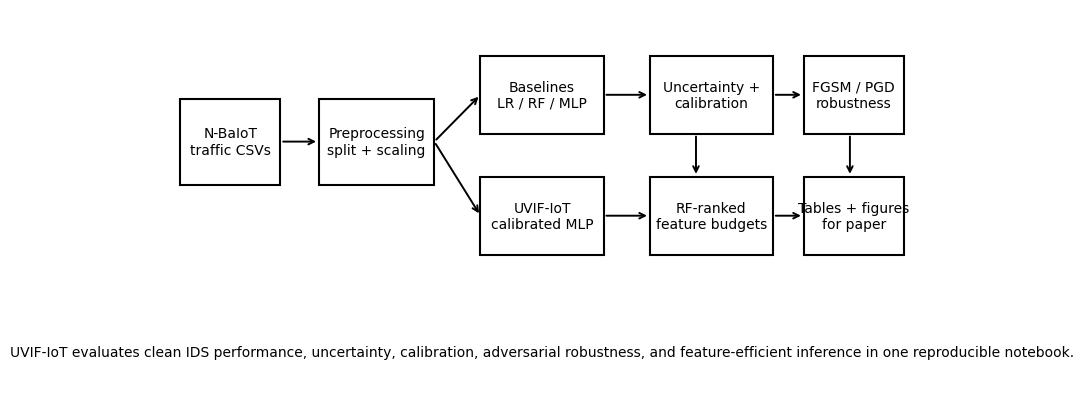

TypeError: object of type 'float' has no len()

In [18]:
# Cell 16 - Framework figure and final reproducibility summary

print("=" * 80)
print("Cell 16 | Framework Figure and Final Reproducibility Summary")
print("=" * 80)

# ---------------------------------------------------------------------
# UVIF-IoT framework diagram
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10.5, 4.2))
ax.axis("off")

boxes = [
    {
        "label": "N-BaIoT\ntraffic CSVs",
        "xy": (0.03, 0.55),
        "w": 0.13,
        "h": 0.22,
    },
    {
        "label": "Preprocessing\nsplit + scaling",
        "xy": (0.21, 0.55),
        "w": 0.15,
        "h": 0.22,
    },
    {
        "label": "Baselines\nLR / RF / MLP",
        "xy": (0.42, 0.68),
        "w": 0.16,
        "h": 0.20,
    },
    {
        "label": "UVIF-IoT\ncalibrated MLP",
        "xy": (0.42, 0.37),
        "w": 0.16,
        "h": 0.20,
    },
    {
        "label": "RF-ranked\nfeature budgets",
        "xy": (0.64, 0.37),
        "w": 0.16,
        "h": 0.20,
    },
    {
        "label": "Uncertainty +\ncalibration",
        "xy": (0.64, 0.68),
        "w": 0.16,
        "h": 0.20,
    },
    {
        "label": "FGSM / PGD\nrobustness",
        "xy": (0.84, 0.68),
        "w": 0.13,
        "h": 0.20,
    },
    {
        "label": "Tables + figures\nfor paper",
        "xy": (0.84, 0.37),
        "w": 0.13,
        "h": 0.20,
    },
]

for box in boxes:
    x, y = box["xy"]
    rect = plt.Rectangle(
        (x, y),
        box["w"],
        box["h"],
        fill=False,
        linewidth=1.5,
    )
    ax.add_patch(rect)
    ax.text(
        x + box["w"] / 2,
        y + box["h"] / 2,
        box["label"],
        ha="center",
        va="center",
        fontsize=10,
    )

arrows = [
    ((0.16, 0.66), (0.21, 0.66)),
    ((0.36, 0.66), (0.42, 0.78)),
    ((0.36, 0.66), (0.42, 0.47)),
    ((0.58, 0.47), (0.64, 0.47)),
    ((0.58, 0.78), (0.64, 0.78)),
    ((0.80, 0.78), (0.84, 0.78)),
    ((0.80, 0.47), (0.84, 0.47)),
    ((0.70, 0.68), (0.70, 0.57)),
    ((0.90, 0.68), (0.90, 0.57)),
]

for start, end in arrows:
    ax.annotate(
        "",
        xy=end,
        xytext=start,
        arrowprops=dict(arrowstyle="->", linewidth=1.4),
    )

ax.text(
    0.5,
    0.12,
    "UVIF-IoT evaluates clean IDS performance, uncertainty, calibration, adversarial robustness, and feature-efficient inference in one reproducible notebook.",
    ha="center",
    va="center",
    fontsize=10,
)

fig.tight_layout()

framework_png = FIGURES_DIR / "uvif_iot_framework_diagram.png"
framework_pdf = FIGURES_DIR / "uvif_iot_framework_diagram.pdf"

fig.savefig(framework_png, dpi=300, bbox_inches="tight")
fig.savefig(framework_pdf, bbox_inches="tight")
plt.show()


# ---------------------------------------------------------------------
# Final result extraction
# ---------------------------------------------------------------------

rf_clean = clean_test_df[clean_test_df["model"] == "Random Forest"].iloc[0]
mlp_clean = clean_test_df[clean_test_df["model"] == "Standard MLP"].iloc[0]
uvif_clean = clean_test_df[clean_test_df["model"] == "UVIF-IoT-Calibrated MLP"].iloc[0]

fe_row = feature_efficiency_df[
    feature_efficiency_df["feature_budget"] == best_feature_budget
].iloc[0]

fgsm_fe_010 = fgsm_fe_df[fgsm_fe_df["epsilon"] == 0.10].iloc[0]
fgsm_full_010 = fgsm_results_df[
    (fgsm_results_df["model"] == "UVIF-IoT-Calibrated MLP")
    & (fgsm_results_df["epsilon"] == 0.10)
].iloc[0]

pgd_fe_010 = pgd_results_df[
    (pgd_results_df["model"] == f"UVIF-IoT-FE-{best_feature_budget}")
    & (pgd_results_df["epsilon"] == 0.10)
].iloc[0]

pgd_full_010 = pgd_results_df[
    (pgd_results_df["model"] == "UVIF-IoT-Calibrated MLP")
    & (pgd_results_df["epsilon"] == 0.10)
].iloc[0]

deployment_fe_cpu = deployment_df[
    (deployment_df["model"] == f"UVIF-IoT-FE-{best_feature_budget}")
    & (deployment_df["runtime_backend"] == "PyTorch CPU")
].iloc[0]

deployment_full_cpu = deployment_df[
    (deployment_df["model"] == "UVIF-IoT-Calibrated MLP")
    & (deployment_df["runtime_backend"] == "PyTorch CPU")
].iloc[0]


# ---------------------------------------------------------------------
# Paper-ready pilot result bullets
# ---------------------------------------------------------------------

result_bullets = f"""# UVIF-IoT Pilot Result Summary

These results are from the balanced pilot configuration of the N-BaIoT dataset.

## Dataset and split

- Pilot samples: {len(y):,}
- Features: {len(feature_names)}
- Train / validation / test: {len(y_train):,} / {len(y_val):,} / {len(y_test):,}
- Binary labels: benign vs attack
- Sampling mode: balanced pilot sample

## Clean detection

- Logistic Regression achieved test Macro-F1 = {clean_test_df[clean_test_df["model"] == "Logistic Regression"]["macro_f1"].iloc[0]:.6f}.
- Random Forest achieved the strongest clean test Macro-F1 = {rf_clean["macro_f1"]:.6f}.
- Standard MLP achieved test Macro-F1 = {mlp_clean["macro_f1"]:.6f}.
- UVIF-IoT calibrated MLP preserved the same clean prediction performance as the standard MLP, with test Macro-F1 = {uvif_clean["macro_f1"]:.6f}.

## Calibration and uncertainty

- Standard MLP test ECE: {test_cal_mlp["ece"]:.6f}.
- Calibrated UVIF-IoT MLP test ECE: {test_cal_temp["ece"]:.6f}.
- Temperature scaling used T = {temperature_value:.6f}.
- Calibrated incorrect predictions had mean entropy = {uncertainty_summary_cal[uncertainty_summary_cal["group"] == "incorrect"]["mean_entropy"].iloc[0]:.6f}.
- Calibrated correct predictions had mean entropy = {uncertainty_summary_cal[uncertainty_summary_cal["group"] == "correct"]["mean_entropy"].iloc[0]:.6f}.

## Feature efficiency

- Selected compact UVIF-IoT budget: {best_feature_budget} features.
- Feature reduction: {fe_row["feature_reduction_pct"]:.2f}%.
- Compact UVIF-IoT test Macro-F1: {fe_row["test_macro_f1"]:.6f}.
- Compact UVIF-IoT test ECE: {fe_row["test_ece"]:.6f}.
- Compact UVIF-IoT trainable parameters: {int(fe_row["trainable_parameters"]):,}.

## Adversarial robustness

- Under FGSM epsilon = 0.10, full calibrated MLP Macro-F1 = {fgsm_full_010["macro_f1"]:.6f}.
- Under FGSM epsilon = 0.10, compact UVIF-IoT Macro-F1 = {fgsm_fe_010["macro_f1"]:.6f}.
- Under corrected PGD epsilon = 0.10 on the 20,000-sample test subset, full calibrated MLP Macro-F1 = {pgd_full_010["macro_f1"]:.6f}.
- Under corrected PGD epsilon = 0.10 on the 20,000-sample test subset, compact UVIF-IoT Macro-F1 = {pgd_fe_010["macro_f1"]:.6f}.

## Deployment footprint

- Full calibrated MLP input features: {int(deployment_full_cpu["n_features"])}.
- Compact UVIF-IoT input features: {int(deployment_fe_cpu["n_features"])}.
- Compact UVIF-IoT saved model size: {deployment_fe_cpu["saved_model_size_mb"]:.6f} MB.
- Full calibrated MLP saved model size: {deployment_full_cpu["saved_model_size_mb"]:.6f} MB.
- CPU timing did not show a speedup for the compact PyTorch model in this pilot run; deployment claims should focus on feature-count and parameter reduction unless further profiling is performed.
"""

result_bullets_path = LOGS_DIR / "paper_ready_pilot_result_summary.md"
with open(result_bullets_path, "w", encoding="utf-8") as f:
    f.write(result_bullets)


# ---------------------------------------------------------------------
# Claim discipline table
# ---------------------------------------------------------------------

claim_rows = [
    {
        "claim": "The notebook is reproducible with fixed seeds and saved configuration files.",
        "status": "supported",
        "evidence": "environment_and_config.json, preprocessing_report.json, exported tables",
    },
    {
        "claim": "The pilot split is balanced for binary benign-vs-attack detection.",
        "status": "supported",
        "evidence": "split_summary_by_binary_label.csv",
    },
    {
        "claim": "Random Forest gives the strongest clean pilot performance.",
        "status": "supported",
        "evidence": "paper_clean_performance.csv",
    },
    {
        "claim": "Temperature scaling improves test ECE for the MLP without changing accuracy.",
        "status": "supported",
        "evidence": "temperature_scaling_report.json",
    },
    {
        "claim": "The 10-feature UVIF-IoT model provides substantial feature and parameter reduction.",
        "status": "supported",
        "evidence": "feature_efficiency_results.csv, deployment_footprint_timing.csv",
    },
    {
        "claim": "The compact model is more stable than the full MLP under the evaluated FGSM and PGD settings.",
        "status": "supported for evaluated pilot attacks",
        "evidence": "fgsm_robustness_results.csv, pgd_robustness_results_subset.csv",
    },
    {
        "claim": "The compact model is generally faster on CPU.",
        "status": "not supported",
        "evidence": "deployment_footprint_timing.csv",
    },
    {
        "claim": "The model reduces energy consumption.",
        "status": "not measured",
        "evidence": "No power or energy instrumentation was used.",
    },
    {
        "claim": "The method detects zero-day attacks.",
        "status": "not tested yet",
        "evidence": "No held-out attack-family experiment has been run.",
    },
]

claim_df = pd.DataFrame(claim_rows)
claim_path = TABLES_DIR / "claim_discipline_table.csv"
claim_df.to_csv(claim_path, index=False)


# ---------------------------------------------------------------------
# Output manifest
# ---------------------------------------------------------------------

manifest_rows = []

for folder, artifact_type in [
    (TABLES_DIR, "table"),
    (FIGURES_DIR, "figure"),
    (MODELS_DIR, "model"),
    (LOGS_DIR, "log"),
]:
    for path in sorted(folder.rglob("*")):
        if path.is_file():
            manifest_rows.append({
                "artifact_type": artifact_type,
                "file_name": path.name,
                "relative_path": str(path.relative_to(PROJECT_ROOT)),
                "size_kb": round(path.stat().st_size / 1024, 3),
            })

output_manifest_df = pd.DataFrame(manifest_rows)
output_manifest_path = LOGS_DIR / "output_artifact_manifest.csv"
output_manifest_df.to_csv(output_manifest_path, index=False)


# ---------------------------------------------------------------------
# Final reproducibility report
# ---------------------------------------------------------------------

final_report = {
    "experiment_name": EXPERIMENT_NAME,
    "status": "pilot pipeline complete",
    "dataset": "N-BaIoT",
    "pilot_samples": int(len(y)),
    "n_features_original": int(len(feature_names)),
    "selected_feature_budget": str(best_feature_budget),
    "selected_feature_count": int(len(selected_features)),
    "selected_feature_reduction_pct": float(fe_row["feature_reduction_pct"]),
    "best_clean_model": str(clean_test_df.iloc[0]["model"]),
    "best_clean_macro_f1": float(clean_test_df.iloc[0]["macro_f1"]),
    "compact_clean_macro_f1": float(fe_row["test_macro_f1"]),
    "compact_fgsm_eps_0_10_macro_f1": float(fgsm_fe_010["macro_f1"]),
    "compact_pgd_eps_0_10_macro_f1_subset": float(pgd_fe_010["macro_f1"]),
    "device": str(DEVICE),
    "cuda_available": bool(CUDA_AVAILABLE),
    "seed": int(SEED),
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "important_note": "These are pilot results from the balanced sampled dataset. Final manuscript claims should use the final-scale run.",
}

final_report_path = LOGS_DIR / "final_pilot_reproducibility_report.json"
with open(final_report_path, "w", encoding="utf-8") as f:
    json.dump(final_report, f, indent=4)


print("\n[Framework figure]")
print(f"Framework PNG/PDF       : {framework_png}")

print("\n[Paper-ready pilot summary]")
print(result_bullets)

print("\n[Claim discipline table]")
print(claim_df.to_string(index=False))

print("\n[Output manifest]")
print(f"Artifacts indexed       : {len(output_manifest_df)}")
print(f"Output manifest         : {output_manifest_path}")

print("\n[Saved]")
print(f"Pilot result summary    : {result_bullets_path}")
print(f"Claim discipline table  : {claim_path}")
print(f"Final reproducibility   : {final_report_path}")

print("\nCell 16 complete.")
print("=" * 80)